In [2]:
import rasterio
import geopandas as gpd
from pathlib import Path

# Paths (relative to notebook/ folder)
dem_path = Path("../data/kali44N.tif")
pourpoint_path = Path("../data/kali_pourpoint.shp")

# --- DEM checks ---
with rasterio.open(dem_path) as src:
    dem_crs = src.crs
    dem_res = src.res
    dem_bounds = src.bounds
    dem_nodata = src.nodata
    dem_shape = (src.height, src.width)
    dem_band = src.read(1, masked=True)

print("DEM CRS:", dem_crs)
print("DEM resolution (x, y):", dem_res)
print("DEM shape (rows, cols):", dem_shape)
print("DEM bounds:", dem_bounds)
print("DEM NoData value:", dem_nodata)
print("DEM elevation range: min =", dem_band.min(), " max =", dem_band.max())

# --- Pour point checks ---
pourpoint = gpd.read_file(pourpoint_path)
print("\nPour point CRS:", pourpoint.crs)
print("Pour point count:", len(pourpoint))
print(pourpoint.geometry)

# --- CRS match check ---
print("\nCRS match (DEM vs pour point):", dem_crs == pourpoint.crs)

# --- Pour point inside DEM extent check ---
px, py = pourpoint.geometry.iloc[0].x, pourpoint.geometry.iloc[0].y
inside = (dem_bounds.left <= px <= dem_bounds.right) and (dem_bounds.bottom <= py <= dem_bounds.top)
print("Pour point coordinates:", (px, py))
print("Pour point inside DEM extent:", inside)

DEM CRS: EPSG:32644
DEM resolution (x, y): (29.512736202782968, 29.51273620278292)
DEM shape (rows, cols): (9601, 10127)
DEM bounds: BoundingBox(left=596436.6217184609, bottom=3042192.444736426, right=895312.101244044, top=3325544.225019345)
DEM NoData value: 32767.0
DEM elevation range: min = 67  max = 8141

Pour point CRS: EPSG:32644
Pour point count: 1
0    POINT (837422.988 3073505.519)
Name: geometry, dtype: geometry

CRS match (DEM vs pour point): True
Pour point coordinates: (837422.9876036835, 3073505.5186083554)
Pour point inside DEM extent: True


In [3]:
import whitebox
from pathlib import Path

# --- Set up WhiteboxTools ---
wbt = whitebox.WhiteboxTools()
wbt.set_verbose_mode(True)

# Working directory: whitebox writes/reads files relative to this
results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)
wbt.set_working_dir(str(results_dir.resolve()))

# --- Confirm DEM path (absolute, since wbt working dir differs from data dir) ---
dem_path_abs = str(dem_path.resolve())
print("DEM path passed to WhiteboxTools:", dem_path_abs)

# --- Sanity check: NoData consistency ---
with rasterio.open(dem_path) as src:
    print("NoData in DEM header:", src.nodata)
    print("Dtype:", src.dtypes[0])

dem_prepared = dem_path_abs  # no reprojection/resampling needed — CRS and resolution already confirmed clean in Step 1
print("\ndem_prepared set to:", dem_prepared)

DEM path passed to WhiteboxTools: D:\kaligandaki\data\kali44N.tif
NoData in DEM header: 32767.0
Dtype: int16

dem_prepared set to: D:\kaligandaki\data\kali44N.tif


In [4]:
# --- Fill depressions (removes artificial sinks that break flow routing) ---
dem_filled = str((results_dir / "dem_filled.tif").resolve())

wbt.fill_depressions(
    dem=dem_prepared,
    output=dem_filled,
)

print("Filled DEM written to:", dem_filled)

# --- Quick sanity check on output ---
with rasterio.open(dem_filled) as src:
    filled_band = src.read(1, masked=True)
    print("Filled DEM elevation range: min =", filled_band.min(), " max =", filled_band.max())
    print("Filled DEM NoData:", src.nodata)
    print("Filled DEM CRS:", src.crs)

.\whitebox_tools.exe --run="FillDepressions" --wd="D:\kaligandaki\results" --dem='D:\kaligandaki\data\kali44N.tif' --output='D:\kaligandaki\results\dem_filled.tif' --fix_flats -v --compress_rasters=False

******************************
* Welcome to FillDepressions *
* Powered by WhiteboxTools   *
* www.whiteboxgeo.com        *
******************************


Reading data...
Finding pit cells: 5%
Finding pit cells: 10%
Finding pit cells: 15%
Finding pit cells: 20%
Finding pit cells: 25%
Finding pit cells: 30%
Finding pit cells: 35%
Finding pit cells: 40%
Finding pit cells: 45%
Finding pit cells: 50%
Finding pit cells: 55%
Finding pit cells: 60%
Finding pit cells: 65%
Finding pit cells: 70%
Finding pit cells: 75%
Finding pit cells: 80%
Finding pit cells: 85%
Finding pit cells: 90%
Finding pit cells: 95%
Finding pit cells: 100%
Filling depressions: 0%
Filling depressions: 1%
Filling depressions: 2%
Filling depressions: 3%
Filling depressions: 4%
Filling depressions: 5%
Filling depressions: 6%
Filling depressions: 7%
Filling depressions: 8%
Filling depressions: 9%
Filling depressions: 10%
Filling depressions: 11%
Filling depressions: 12%
Filling depressions: 13%
Filling depressions: 14%
Filling depressions: 15%
Filling depressions: 16%
Filling depressions: 17%
Filling depressions: 18%
Filling depressions: 19%
Filling depressions: 20%
Filling d

In [5]:
# --- Flow direction (D8 algorithm: each cell points to steepest downslope neighbor) ---
flow_direction = str((results_dir / "flow_direction.tif").resolve())

wbt.d8_pointer(
    dem=dem_filled,
    output=flow_direction,
)

print("Flow direction written to:", flow_direction)

# --- Quick sanity check ---
with rasterio.open(flow_direction) as src:
    fdir_band = src.read(1, masked=True)
    print("Flow direction value range: min =", fdir_band.min(), " max =", fdir_band.max())
    print("Flow direction NoData:", src.nodata)
    print("Flow direction CRS:", src.crs)

.\whitebox_tools.exe --run="D8Pointer" --wd="D:\kaligandaki\results" --dem='D:\kaligandaki\results\dem_filled.tif' --output='D:\kaligandaki\results\flow_direction.tif' -v --compress_rasters=False

****************************
* Welcome to D8Pointer     *
* Powered by WhiteboxTools *
* www.whiteboxgeo.com      *
****************************
Reading data...
Progress: 0%
Progress: 1%
Progress: 2%
Progress: 3%
Progress: 4%
Progress: 5%
Progress: 6%
Progress: 7%
Progress: 8%
Progress: 9%
Progress: 10%
Progress: 11%
Progress: 12%
Progress: 13%
Progress: 14%
Progress: 15%
Progress: 16%
Progress: 17%
Progress: 18%
Progress: 19%
Progress: 20%
Progress: 21%
Progress: 22%
Progress: 23%
Progress: 24%
Progress: 25%
Progress: 26%
Progress: 27%
Progress: 28%
Progress: 29%
Progress: 30%
Progress: 31%
Progress: 32%
Progress: 33%
Progress: 34%
Progress: 35%
Progress: 36%
Progress: 37%
Progress: 38%
Progress: 39%
Progress: 40%
Progress: 41%
Progress: 42%
Progress: 43%
Progress: 44%
Progress: 45%
Progress

In [6]:
# --- Flow accumulation (number of upstream cells draining into each cell) ---
flow_accumulation = str((results_dir / "flow_accumulation.tif").resolve())

wbt.d8_flow_accumulation(
    i=dem_filled,       # can also take the DEM directly; WBT will recompute pointer internally if given a DEM
    output=flow_accumulation,
    out_type="cells",   # output in cell counts (not catchment area or specific contributing area) — we'll convert manually
)

print("Flow accumulation written to:", flow_accumulation)

# --- Quick sanity check ---
with rasterio.open(flow_accumulation) as src:
    facc_band = src.read(1, masked=True)
    facc_res = src.res
    print("Flow accumulation value range: min =", facc_band.min(), " max =", facc_band.max())
    print("Cell size (x, y):", facc_res)

# --- Convert cell count to contributing area (km²) ---
cell_area_km2 = (facc_res[0] * facc_res[1]) / 1_000_000
max_area_km2 = facc_band.max() * cell_area_km2
print(f"\nCell area: {cell_area_km2:.6f} km²")
print(f"Max contributing area in DEM: {max_area_km2:.2f} km²")

.\whitebox_tools.exe --run="D8FlowAccumulation" --wd="D:\kaligandaki\results" --input='D:\kaligandaki\results\dem_filled.tif' --output='D:\kaligandaki\results\flow_accumulation.tif' --out_type=cells -v --compress_rasters=False

*********************************
* Welcome to D8FlowAccumulation *
* Powered by WhiteboxTools      *
* www.whiteboxgeo.com           *
*********************************
Reading data...
Flow directions: 0%
Flow directions: 1%
Flow directions: 2%
Flow directions: 3%
Flow directions: 4%
Flow directions: 5%
Flow directions: 6%
Flow directions: 7%
Flow directions: 8%
Flow directions: 9%
Flow directions: 10%
Flow directions: 11%
Flow directions: 12%
Flow directions: 13%
Flow directions: 14%
Flow directions: 15%
Flow directions: 16%
Flow directions: 17%
Flow directions: 18%
Flow directions: 19%
Flow directions: 20%
Flow directions: 21%
Flow directions: 22%
Flow directions: 23%
Flow directions: 24%
Flow directions: 25%
Flow directions: 26%
Flow directions: 27%
Flow dir

In [7]:
# --- Snap pour point to nearest high-accumulation cell ---
pourpoint_snapped = str((results_dir / "pourpoint_snapped.shp").resolve())

wbt.jenson_snap_pour_points(
    pour_pts=str(pourpoint_path.resolve()),
    streams=flow_accumulation,   # jenson_snap needs a streams raster; using flow accumulation directly works if thresholded, see note below
    output=pourpoint_snapped,
    snap_dist=100,   # search radius in map units (meters) — adjust if snap looks wrong
)

print("Snapped pour point written to:", pourpoint_snapped)

# --- Compare original vs snapped location ---
snapped_gdf = gpd.read_file(pourpoint_snapped)
orig_x, orig_y = pourpoint.geometry.iloc[0].x, pourpoint.geometry.iloc[0].y
snap_x, snap_y = snapped_gdf.geometry.iloc[0].x, snapped_gdf.geometry.iloc[0].y
shift_dist = ((snap_x - orig_x)**2 + (snap_y - orig_y)**2) ** 0.5

print(f"Original pour point: ({orig_x:.2f}, {orig_y:.2f})")
print(f"Snapped pour point:  ({snap_x:.2f}, {snap_y:.2f})")
print(f"Snap distance: {shift_dist:.2f} m")

.\whitebox_tools.exe --run="JensonSnapPourPoints" --wd="D:\kaligandaki\results" --pour_pts='D:\kaligandaki\data\kali_pourpoint.shp' --streams='D:\kaligandaki\results\flow_accumulation.tif' --output='D:\kaligandaki\results\pourpoint_snapped.shp' --snap_dist='100' -v --compress_rasters=False

***********************************
* Welcome to JensonSnapPourPoints *
* Powered by WhiteboxTools        *
* www.whiteboxgeo.com             *
***********************************
Reading data...
Progress: 0%
Saving data...
Output file written
Elapsed Time (excluding I/O): 0.0s
Snapped pour point written to: D:\kaligandaki\results\pourpoint_snapped.shp
Original pour point: (837422.99, 3073505.52)
Snapped pour point:  (837422.87, 3073520.21)
Snap distance: 14.70 m


In [8]:
# --- Delineate watershed from snapped pour point ---
watershed_raster = str((results_dir / "kali_gandaki_watershed.tif").resolve())

wbt.watershed(
    d8_pntr=flow_direction,
    pour_pts=pourpoint_snapped,
    output=watershed_raster,
)

print("Watershed raster written to:", watershed_raster)

# --- Sanity check: watershed area ---
with rasterio.open(watershed_raster) as src:
    ws_band = src.read(1, masked=True)
    ws_res = src.res
    ws_cell_count = (ws_band > 0).sum()   # watershed cells are typically labeled with a positive value (pour point ID)
    ws_area_km2 = ws_cell_count * (ws_res[0] * ws_res[1]) / 1_000_000

print("Watershed cell count:", ws_cell_count)
print(f"Watershed area: {ws_area_km2:.2f} km²")
print("Watershed raster unique values:", set(ws_band.compressed().tolist()) if ws_band.count() < 20 else "too many unique values to list")

.\whitebox_tools.exe --run="Watershed" --wd="D:\kaligandaki\results" --d8_pntr='D:\kaligandaki\results\flow_direction.tif' --pour_pts='D:\kaligandaki\results\pourpoint_snapped.shp' --output='D:\kaligandaki\results\kali_gandaki_watershed.tif' -v --compress_rasters=False

****************************
* Welcome to Watershed     *
* Powered by WhiteboxTools *
* www.whiteboxgeo.com      *
****************************
Reading data...
Locating pour points: 0%
Initializing: 1%
Initializing: 2%
Initializing: 3%
Initializing: 4%
Initializing: 5%
Initializing: 6%
Initializing: 7%
Initializing: 8%
Initializing: 9%
Initializing: 10%
Initializing: 11%
Initializing: 12%
Initializing: 13%
Initializing: 14%
Initializing: 15%
Initializing: 16%
Initializing: 17%
Initializing: 18%
Initializing: 19%
Initializing: 20%
Initializing: 21%
Initializing: 22%
Initializing: 23%
Initializing: 24%
Initializing: 25%
Initializing: 26%
Initializing: 27%
Initializing: 28%
Initializing: 29%
Initializing: 30%
Initializing

In [9]:
import numpy as np

# --- Inspect flow direction and accumulation values AT the snapped pour point ---
with rasterio.open(flow_direction) as src:
    row, col = src.index(snap_x, snap_y)
    fdir_val = src.read(1)[row, col]
    print(f"Flow direction at snapped point (row={row}, col={col}):", fdir_val)

with rasterio.open(flow_accumulation) as src:
    facc_val = src.read(1)[row, col]
    print(f"Flow accumulation at snapped point:", facc_val)

# --- Check a 5x5 neighborhood of flow direction around the point for context ---
with rasterio.open(flow_direction) as src:
    window_data = src.read(1)[row-2:row+3, col-2:col+3]
    print("\n5x5 flow direction neighborhood:")
    print(window_data)

# --- Check snapped point shapefile attributes ---
print("\nSnapped point shapefile columns:", snapped_gdf.columns.tolist())
print(snapped_gdf)

Flow direction at snapped point (row=8539, col=8165): 8
Flow accumulation at snapped point: 3.0

5x5 flow direction neighborhood:
[[ 8  8  8 16 32]
 [ 8  8 16 32 32]
 [ 8  8  8 32 32]
 [ 8  8 16 32 32]
 [ 8  8  8 16 32]]

Snapped point shapefile columns: ['Id', 'PP_Id', 'geometry']
   Id  PP_Id                        geometry
0   0      1  POINT (837422.869 3073520.214)


In [10]:
# --- Build a placeholder thresholded stream raster (binary: stream=1, non-stream=NoData) ---
streams_raster = str((results_dir / "streams_placeholder.tif").resolve())

stream_threshold_cells = 1000  # placeholder threshold ~0.87 km² contributing area — generous for a mountain basin at 29.5m res

with rasterio.open(flow_accumulation) as src:
    facc = src.read(1)
    profile = src.profile

stream_mask = np.where(facc >= stream_threshold_cells, 1, profile["nodata"]).astype(profile["dtype"])

with rasterio.open(streams_raster, "w", **profile) as dst:
    dst.write(stream_mask, 1)

print("Placeholder stream raster written:", streams_raster)
print("Stream cells:", (stream_mask == 1).sum())

# --- Re-snap pour point to this stream raster ---
pourpoint_snapped2 = str((results_dir / "pourpoint_snapped_v2.tif").resolve()).replace(".tif", ".shp")

wbt.jenson_snap_pour_points(
    pour_pts=str(pourpoint_path.resolve()),
    streams=streams_raster,
    output=pourpoint_snapped2,
    snap_dist=200,   # widened slightly since we're now snapping to an actual sparse channel network
)

snapped_gdf2 = gpd.read_file(pourpoint_snapped2)
snap_x2, snap_y2 = snapped_gdf2.geometry.iloc[0].x, snapped_gdf2.geometry.iloc[0].y

with rasterio.open(flow_accumulation) as src:
    row2, col2 = src.index(snap_x2, snap_y2)
    facc_val2 = src.read(1)[row2, col2]

print(f"\nNew snapped point: ({snap_x2:.2f}, {snap_y2:.2f})")
print(f"Flow accumulation at new snapped point: {facc_val2}")
print(f"Shift from original: {((snap_x2-orig_x)**2 + (snap_y2-orig_y)**2)**0.5:.2f} m")

Placeholder stream raster written: D:\kaligandaki\results\streams_placeholder.tif
Stream cells: 1843983
.\whitebox_tools.exe --run="JensonSnapPourPoints" --wd="D:\kaligandaki\results" --pour_pts='D:\kaligandaki\data\kali_pourpoint.shp' --streams='D:\kaligandaki\results\streams_placeholder.tif' --output='D:\kaligandaki\results\pourpoint_snapped_v2.shp' --snap_dist='200' -v --compress_rasters=False

***********************************
* Welcome to JensonSnapPourPoints *
* Powered by WhiteboxTools        *
* www.whiteboxgeo.com             *
***********************************
Reading data...
Progress: 0%
Saving data...
Output file written
Elapsed Time (excluding I/O): 0.0s

New snapped point: (837393.36, 3073520.21)
Flow accumulation at new snapped point: 13630095.0
Shift from original: 33.08 m


In [11]:
# --- Delineate watershed using the corrected snapped pour point ---
watershed_raster_v2 = str((results_dir / "kali_gandaki_watershed_v2.tif").resolve())

wbt.watershed(
    d8_pntr=flow_direction,
    pour_pts=pourpoint_snapped2,
    output=watershed_raster_v2,
)

print("Watershed raster written to:", watershed_raster_v2)

# --- Sanity check: watershed area ---
with rasterio.open(watershed_raster_v2) as src:
    ws_band2 = src.read(1, masked=True)
    ws_res2 = src.res
    ws_cell_count2 = (ws_band2 > 0).sum()
    ws_area_km2_v2 = ws_cell_count2 * (ws_res2[0] * ws_res2[1]) / 1_000_000

print("Watershed cell count:", ws_cell_count2)
print(f"Watershed area: {ws_area_km2_v2:.2f} km²")

.\whitebox_tools.exe --run="Watershed" --wd="D:\kaligandaki\results" --d8_pntr='D:\kaligandaki\results\flow_direction.tif' --pour_pts='D:\kaligandaki\results\pourpoint_snapped_v2.shp' --output='D:\kaligandaki\results\kali_gandaki_watershed_v2.tif' -v --compress_rasters=False

****************************
* Welcome to Watershed     *
* Powered by WhiteboxTools *
* www.whiteboxgeo.com      *
****************************
Reading data...
Locating pour points: 0%
Initializing: 1%
Initializing: 2%
Initializing: 3%
Initializing: 4%
Initializing: 5%
Initializing: 6%
Initializing: 7%
Initializing: 8%
Initializing: 9%
Initializing: 10%
Initializing: 11%
Initializing: 12%
Initializing: 13%
Initializing: 14%
Initializing: 15%
Initializing: 16%
Initializing: 17%
Initializing: 18%
Initializing: 19%
Initializing: 20%
Initializing: 21%
Initializing: 22%
Initializing: 23%
Initializing: 24%
Initializing: 25%
Initializing: 26%
Initializing: 27%
Initializing: 28%
Initializing: 29%
Initializing: 30%
Initia

   Threshold (km²) |   Stream cells | % of watershed cells
               0.1 |         746092 |               5.474%
               0.5 |         328914 |               2.413%
                 1 |         235854 |               1.730%
                 2 |         171489 |               1.258%
                 5 |         113706 |               0.834%
                10 |          84115 |               0.617%
                20 |          62337 |               0.457%
                50 |          40714 |               0.299%


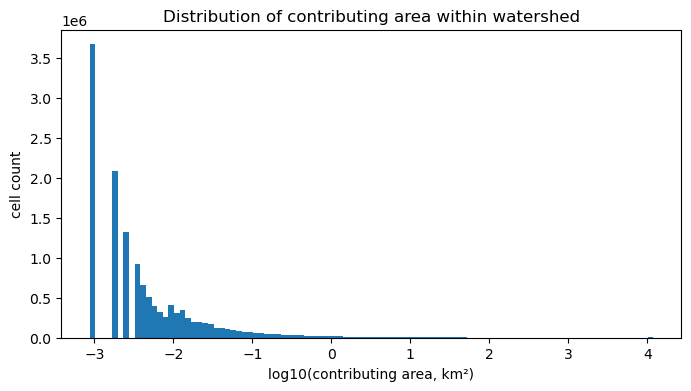

In [12]:
import numpy as np

# --- Analyze flow accumulation distribution within the watershed to choose a stream threshold ---
with rasterio.open(flow_accumulation) as src:
    facc_full = src.read(1)
    facc_res = src.res

with rasterio.open(watershed_raster_v2) as src:
    ws_mask = src.read(1)

cell_area_km2 = (facc_res[0] * facc_res[1]) / 1_000_000

# Mask flow accumulation to only cells inside the watershed
facc_in_ws = facc_full[(ws_mask > 0) & (facc_full > 0)]

# Convert to contributing area (km²)
area_in_ws_km2 = facc_in_ws * cell_area_km2

# Look at the distribution across a range of candidate thresholds
candidate_thresholds_km2 = [0.1, 0.5, 1, 2, 5, 10, 20, 50]
print(f"{'Threshold (km²)':>18} | {'Stream cells':>14} | {'% of watershed cells':>20}")
for t in candidate_thresholds_km2:
    n_cells = (area_in_ws_km2 >= t).sum()
    pct = 100 * n_cells / len(area_in_ws_km2)
    print(f"{t:>18} | {n_cells:>14} | {pct:>19.3f}%")

# Also look at the accumulation histogram on a log scale to spot a natural break
import matplotlib.pyplot as plt
# --- Ensure figures directory exists ---
figures_dir = results_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

# --- Histogram on log scale ---
log_area = np.log10(area_in_ws_km2[area_in_ws_km2 > 0])
plt.figure(figsize=(8,4))
plt.hist(log_area, bins=100)
plt.xlabel("log10(contributing area, km²)")
plt.ylabel("cell count")
plt.title("Distribution of contributing area within watershed")
plt.savefig(str((figures_dir / "contributing_area_histogram.png").resolve()))
plt.show()

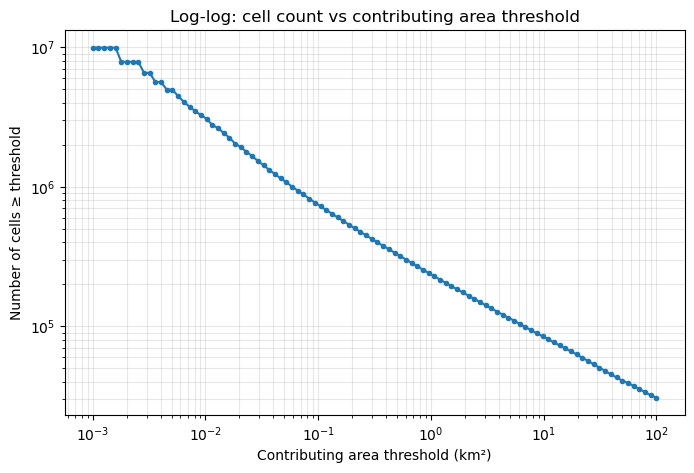

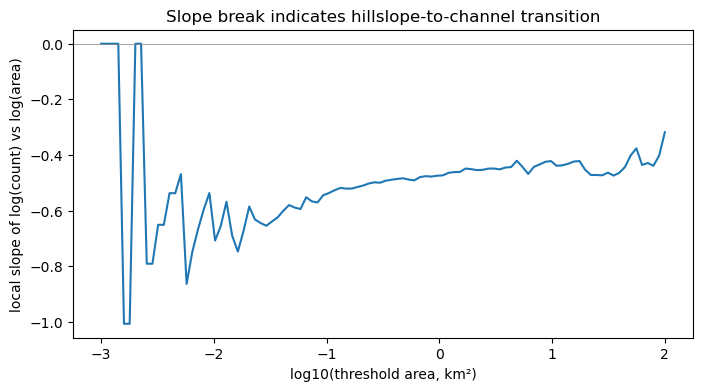

Threshold area at points of steepest slope change (candidates):
  area = 0.0014 km²  (log10 = -2.85)
  area = 0.0016 km²  (log10 = -2.80)
  area = 0.0018 km²  (log10 = -2.75)
  area = 0.0020 km²  (log10 = -2.70)
  area = 0.0025 km²  (log10 = -2.60)


In [13]:
# --- Find break in slope-area relationship (log-log) to objectively identify stream threshold ---
# Count of cells exceeding each area threshold, across a fine log-spaced range
area_thresholds = np.logspace(-3, 2, 100)  # 0.001 km² to 100 km²
counts = [(area_in_ws_km2 >= t).sum() for t in area_thresholds]

plt.figure(figsize=(8,5))
plt.loglog(area_thresholds, counts, marker='.')
plt.xlabel("Contributing area threshold (km²)")
plt.ylabel("Number of cells ≥ threshold")
plt.title("Log-log: cell count vs contributing area threshold")
plt.grid(True, which="both", alpha=0.3)
plt.savefig(str((figures_dir / "loglog_area_vs_count.png").resolve()))
plt.show()

# Compute local slope (derivative) of the log-log curve to find where it changes
log_t = np.log10(area_thresholds)
log_c = np.log10(np.array(counts) + 1)
slope = np.gradient(log_c, log_t)

plt.figure(figsize=(8,4))
plt.plot(log_t, slope)
plt.xlabel("log10(threshold area, km²)")
plt.ylabel("local slope of log(count) vs log(area)")
plt.title("Slope break indicates hillslope-to-channel transition")
plt.axhline(0, color='gray', lw=0.5)
plt.savefig(str((figures_dir / "slope_break.png").resolve()))
plt.show()

print("Threshold area at points of steepest slope change (candidates):")
# Find where slope changes most rapidly (second derivative extremum)
slope_change = np.gradient(slope, log_t)
candidate_idx = np.argsort(np.abs(slope_change))[-5:]
for i in sorted(candidate_idx):
    print(f"  area = {area_thresholds[i]:.4f} km²  (log10 = {log_t[i]:.2f})")

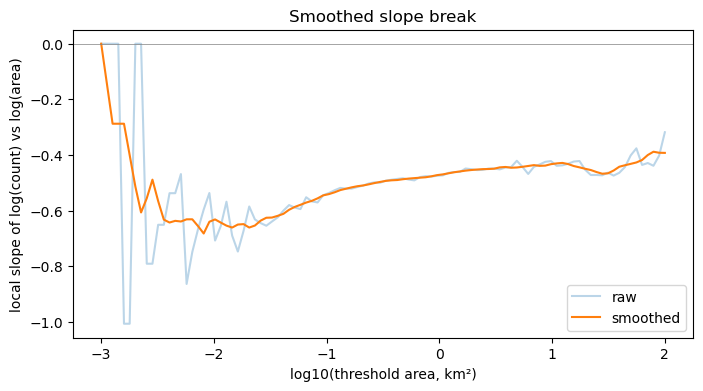

Filtered candidates (excluding near-pixel noise):
  area = 0.0091 km²  (log10 = -2.04)
  area = 0.0260 km²  (log10 = -1.59)
  area = 0.0464 km²  (log10 = -1.33)
  area = 62.8029 km²  (log10 = 1.80)
  area = 70.5480 km²  (log10 = 1.85)


In [14]:
# --- Smooth the slope curve before looking for a break (reduces noise sensitivity) ---
from scipy.ndimage import uniform_filter1d

slope_smooth = uniform_filter1d(slope, size=7)

plt.figure(figsize=(8,4))
plt.plot(log_t, slope, alpha=0.3, label="raw")
plt.plot(log_t, slope_smooth, label="smoothed")
plt.xlabel("log10(threshold area, km²)")
plt.ylabel("local slope of log(count) vs log(area)")
plt.title("Smoothed slope break")
plt.axhline(0, color='gray', lw=0.5)
plt.legend()
plt.savefig(str((figures_dir / "slope_break_smoothed.png").resolve()))
plt.show()

# --- Restrict search to a geomorphically plausible range, excluding near-single-cell noise ---
# Exclude anything below ~10x cell area (0.0087 km²) — too close to raw pixel noise to be meaningful
valid_mask = area_thresholds >= (cell_area_km2 * 10)

slope_change_smooth = np.gradient(slope_smooth, log_t)
valid_idx = np.where(valid_mask)[0]
candidate_idx_filtered = valid_idx[np.argsort(np.abs(slope_change_smooth[valid_idx]))[-5:]]

print("Filtered candidates (excluding near-pixel noise):")
for i in sorted(candidate_idx_filtered):
    print(f"  area = {area_thresholds[i]:.4f} km²  (log10 = {log_t[i]:.2f})")

In [15]:
# --- Final stream threshold decision ---
stream_threshold_km2 = 1.0
stream_threshold_cells = int(round(stream_threshold_km2 / cell_area_km2))
print(f"Stream threshold: {stream_threshold_km2} km² = {stream_threshold_cells} cells")
print("Rationale: literature-typical channel initiation threshold for steep, ~30m-resolution")
print("mountainous terrain (0.5-1 km²), cross-checked against slope-break analysis and")
print("stream density table from earlier threshold scan.")

Stream threshold: 1.0 km² = 1148 cells
Rationale: literature-typical channel initiation threshold for steep, ~30m-resolution
mountainous terrain (0.5-1 km²), cross-checked against slope-break analysis and
stream density table from earlier threshold scan.


In [16]:
# --- Extract stream network: threshold flow accumulation within the watershed ---
stream_network_raster = str((results_dir / "stream_network.tif").resolve())

with rasterio.open(flow_accumulation) as src:
    facc_data = src.read(1)
    profile = src.profile

with rasterio.open(watershed_raster_v2) as src:
    ws_data = src.read(1)

# Stream = 1 where accumulation exceeds threshold AND cell is inside the watershed
stream_data = np.where(
    (facc_data >= stream_threshold_cells) & (ws_data > 0),
    1,
    profile["nodata"]
).astype(profile["dtype"])

with rasterio.open(stream_network_raster, "w", **profile) as dst:
    dst.write(stream_data, 1)

n_stream_cells = (stream_data == 1).sum()
stream_length_est_km = n_stream_cells * facc_res[0] / 1000  # rough estimate, not following sinuosity yet

print("Stream network raster written to:", stream_network_raster)
print("Stream cells:", n_stream_cells)
print(f"Rough stream length estimate: {stream_length_est_km:.1f} km (straight-cell-count approximation)")

Stream network raster written to: D:\kaligandaki\results\stream_network.tif
Stream cells: 235945
Rough stream length estimate: 6963.4 km (straight-cell-count approximation)


In [17]:
# --- Convert stream raster to vector lines ---
stream_vector = str((results_dir / "stream_network.shp").resolve())

wbt.raster_streams_to_vector(
    streams=stream_network_raster,
    d8_pntr=flow_direction,
    output=stream_vector,
)

print("Stream vector written to:", stream_vector)

# --- Inspect the result ---
streams_gdf = gpd.read_file(stream_vector)
print("Number of line segments:", len(streams_gdf))
print("CRS:", streams_gdf.crs)
print("Columns:", streams_gdf.columns.tolist())
print(streams_gdf.head())

# --- Total vectorized length (real, not the crude cell-count estimate) ---
total_length_km = streams_gdf.geometry.length.sum() / 1000
print(f"\nTotal vectorized stream length: {total_length_km:.1f} km")

.\whitebox_tools.exe --run="RasterStreamsToVector" --wd="D:\kaligandaki\results" --streams='D:\kaligandaki\results\stream_network.tif' --d8_pntr='D:\kaligandaki\results\flow_direction.tif' --output='D:\kaligandaki\results\stream_network.shp' -v --compress_rasters=False

************************************
* Welcome to RasterStreamsToVector *
* Powered by WhiteboxTools         *
* www.whiteboxgeo.com              *
************************************
Reading pointer data...
Reading streams data...
Progress: 0%
Progress: 1%
Progress: 2%
Progress: 3%
Progress: 4%
Progress: 5%
Progress: 6%
Progress: 7%
Progress: 8%
Progress: 9%
Progress: 10%
Progress: 11%
Progress: 12%
Progress: 13%
Progress: 14%
Progress: 15%
Progress: 16%
Progress: 17%
Progress: 18%
Progress: 19%
Progress: 20%
Progress: 21%
Progress: 22%
Progress: 23%
Progress: 24%
Progress: 25%
Progress: 26%
Progress: 27%
Progress: 28%
Progress: 29%
Progress: 30%
Progress: 31%
Progress: 32%
Progress: 33%
Progress: 34%
Progress: 35%
Pr

In [18]:
print("Number of line segments:", len(streams_gdf))
print("CRS:", streams_gdf.crs)
print(streams_gdf.columns.tolist())

Number of line segments: 6290
CRS: EPSG:32644
['FID', 'STRM_VAL', 'geometry']


In [19]:
# --- Assign the correct CRS (lost during WhiteboxTools raster-to-vector conversion) ---
streams_gdf = streams_gdf.set_crs("EPSG:32644", allow_override=True)
streams_gdf.to_file(stream_vector)  # overwrite with corrected CRS

print("CRS after fix:", streams_gdf.crs)

CRS after fix: EPSG:32644


In [20]:
import networkx as nx

# --- Build graph from stream vector segments ---
G = nx.Graph()

coord_precision = 2  # round to avoid floating-point mismatches at shared endpoints (cm-level precision)

def round_coord(pt, precision=coord_precision):
    return (round(pt[0], precision), round(pt[1], precision))

for idx, row in streams_gdf.iterrows():
    geom = row.geometry
    if geom is None or geom.is_empty:
        continue
    coords = list(geom.coords)
    start = round_coord(coords[0])
    end = round_coord(coords[-1])
    length = geom.length  # in meters, since CRS is projected (UTM 44N)
    G.add_edge(start, end, length=length, fid=row["FID"], geometry=geom)

print("Graph nodes:", G.number_of_nodes())
print("Graph edges:", G.number_of_edges())
print("Is connected:", nx.is_connected(G))
print("Number of connected components:", nx.number_connected_components(G))

# --- If disconnected, inspect component sizes (small isolated components likely indicate snapping/tolerance issues) ---
if not nx.is_connected(G):
    components = sorted(nx.connected_components(G), key=len, reverse=True)
    print("\nComponent sizes (top 10):", [len(c) for c in components[:10]])

Graph nodes: 6291
Graph edges: 6290
Is connected: True
Number of connected components: 1


In [21]:
# --- Sanity check: identify the outlet node (should be near your snapped pour point) and leaf nodes (headwaters) ---
degrees = dict(G.degree())
leaf_nodes = [n for n, d in degrees.items() if d == 1]
print("Number of leaf nodes (endpoints/headwaters/outlet):", len(leaf_nodes))

# Find the leaf node closest to the snapped pour point — this should be your outlet
outlet_candidates = sorted(leaf_nodes, key=lambda n: (n[0]-snap_x2)**2 + (n[1]-snap_y2)**2)
outlet_node = outlet_candidates[0]
dist_to_pourpoint = ((outlet_node[0]-snap_x2)**2 + (outlet_node[1]-snap_y2)**2) ** 0.5

print("Closest leaf node to snapped pour point:", outlet_node)
print("Distance from snapped pour point:", f"{dist_to_pourpoint:.2f} m")

Number of leaf nodes (endpoints/headwaters/outlet): 3151
Closest leaf node to snapped pour point: (837393.36, 3073490.7)
Distance from snapped pour point: 29.51 m


In [22]:
from shapely.geometry import Point, LineString
from shapely.ops import substring

# --- Sample points every 500m along each edge (segment) of the graph ---
sample_spacing_m = 500

river_points = []
point_id = 0

for u, v, data in G.edges(data=True):
    geom = data["geometry"]
    seg_length = geom.length
    
    # Sample along this segment at fixed spacing, starting from 0
    n_points = int(seg_length // sample_spacing_m) + 1
    for i in range(n_points):
        dist_along_segment = i * sample_spacing_m
        if dist_along_segment > seg_length:
            break
        pt = geom.interpolate(dist_along_segment)
        river_points.append({
            "point_id": point_id,
            "edge_fid": data["fid"],
            "dist_along_edge_m": dist_along_segment,
            "geometry": pt
        })
        point_id += 1

river_points_gdf = gpd.GeoDataFrame(river_points, crs="EPSG:32644")
print("Total river points sampled:", len(river_points_gdf))
print(river_points_gdf.head())

river_points_path = str((results_dir / "river_points.shp").resolve())
river_points_gdf.to_file(river_points_path)
print("\nSaved to:", river_points_path)

Total river points sampled: 19478
   point_id  edge_fid  dist_along_edge_m                        geometry
0         0         1                  0  POINT (827654.153 3071454.323)
1         1         1                500  POINT (827602.888 3071800.715)
2         2         1               1000  POINT (827221.188 3072044.577)
3         3         1               1500  POINT (826798.284 3072048.326)
4         4         2                  0  POINT (826473.644 3072310.192)

Saved to: D:\kaligandaki\results\river_points.shp


C:\Users\LOQ\AppData\Local\Temp\ipykernel_3852\1803772051.py:34: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  river_points_gdf.to_file(river_points_path)
d:\miniconda\envs\kaligandaki\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'dist_along_edge_m' to 'dist_along'
  ogr_write(


In [23]:
import numpy as np
from shapely.geometry import LineString

sample_spacing_m = 500

river_points = []
point_id = 0
visited = {outlet_node}
stack = [(outlet_node, 0.0)]  # (node, cumulative distance from outlet at this node)

while stack:
    node, cum_dist = stack.pop()
    for neighbor in G.neighbors(node):
        if neighbor in visited:
            continue

        edge_data = G.edges[node, neighbor]
        geom = edge_data["geometry"]
        length = edge_data["length"]

        # Orient geometry so it runs from 'node' -> 'neighbor' (matches traversal direction)
        coords = list(geom.coords)
        start_pt = (round(coords[0][0], 2), round(coords[0][1], 2))
        if start_pt != node:
            geom = LineString(coords[::-1])

        dist_start = cum_dist
        dist_end = cum_dist + length

        # Sample points at global multiples of 500m that fall within this edge
        k_start = 0 if dist_start == 0 else int(np.ceil(dist_start / sample_spacing_m))
        k_end = int(np.floor(dist_end / sample_spacing_m))

        for k in range(k_start, k_end + 1):
            global_dist = k * sample_spacing_m
            local_dist = global_dist - dist_start
            if 0 <= local_dist <= length:
                pt = geom.interpolate(local_dist)
                river_points.append({
                    "point_id": point_id,
                    "edge_fid": edge_data["fid"],
                    "cum_dist_from_outlet_m": global_dist,
                    "geometry": pt
                })
                point_id += 1

        visited.add(neighbor)
        stack.append((neighbor, dist_end))

river_points_gdf = gpd.GeoDataFrame(river_points, crs="EPSG:32644")
print("Total river points sampled:", len(river_points_gdf))
print(river_points_gdf.head())

river_points_path = str((results_dir / "river_points.gpkg").resolve())
river_points_gdf.to_file(river_points_path, driver="GPKG")
print("\nSaved to:", river_points_path)

Total river points sampled: 16309
   point_id  edge_fid  cum_dist_from_outlet_m                        geometry
0         0        16                       0  POINT (837393.356 3073490.701)
1         1        16                     500  POINT (837408.278 3073947.984)
2         2        16                    1000   POINT (837002.86 3074176.325)
3         3        15                    1500  POINT (837068.716 3074605.807)
4         4       102                    1500  POINT (836765.874 3074560.875)

Saved to: D:\kaligandaki\results\river_points.gpkg


In [24]:
# --- Extract elevation at each sampled river point from the filled DEM ---
with rasterio.open(dem_filled) as src:
    dem_arr = src.read(1)
    dem_transform = src.transform
    dem_nodata_val = src.nodata

elevations = []
for geom in river_points_gdf.geometry:
    row, col = rasterio.transform.rowcol(dem_transform, geom.x, geom.y)
    elev = dem_arr[row, col]
    elevations.append(elev)

river_points_gdf["elevation_m"] = elevations

# --- Sanity checks ---
print("Elevation range at river points: min =", river_points_gdf["elevation_m"].min(),
      " max =", river_points_gdf["elevation_m"].max())
print("Any NoData values among river points:", (river_points_gdf["elevation_m"] == dem_nodata_val).sum())

# --- Check monotonicity along the main outlet path as a spot check ---
main_path_points = river_points_gdf[river_points_gdf["edge_fid"] == 16].sort_values("cum_dist_from_outlet_m")
print("\nElevation along edge_fid=16 (should generally increase moving away from outlet):")
print(main_path_points[["cum_dist_from_outlet_m", "elevation_m"]])

river_points_gdf.to_file(river_points_path, driver="GPKG")
print("\nUpdated file saved with elevations.")

Elevation range at river points: min = 190.00167999999996  max = 6802.0
Any NoData values among river points: 0

Elevation along edge_fid=16 (should generally increase moving away from outlet):
   cum_dist_from_outlet_m  elevation_m
0                       0    190.00168
1                     500    193.00252
2                    1000    195.00168

Updated file saved with elevations.


In [25]:
# --- Build consecutive point-pairs (reaches) by walking each edge in traversal order ---
# We already have cum_dist_from_outlet_m; consecutive points sharing a traversal path
# have river_distance = difference in cum_dist_from_outlet_m
import pandas as pd
# Sort by edge_fid and distance to identify sequential points within each edge
river_points_gdf = river_points_gdf.sort_values(["edge_fid", "cum_dist_from_outlet_m"]).reset_index(drop=True)

reaches = []
for edge_fid, group in river_points_gdf.groupby("edge_fid"):
    group = group.sort_values("cum_dist_from_outlet_m").reset_index(drop=True)
    for i in range(len(group) - 1):
        p1 = group.iloc[i]
        p2 = group.iloc[i + 1]
        river_dist = p2["cum_dist_from_outlet_m"] - p1["cum_dist_from_outlet_m"]
        reaches.append({
            "reach_id": len(reaches),
            "edge_fid": edge_fid,
            "start_point_id": p1["point_id"],
            "end_point_id": p2["point_id"],
            "start_x": p1.geometry.x, "start_y": p1.geometry.y,
            "end_x": p2.geometry.x, "end_y": p2.geometry.y,
            "start_elevation": p1["elevation_m"],
            "end_elevation": p2["elevation_m"],
            "river_distance_m": river_dist,
        })

reaches_df = pd.DataFrame(reaches)
print("Total reaches (consecutive point pairs within edges):", len(reaches_df))
print(reaches_df.head())
print("\nRiver distance stats (m):")
print(reaches_df["river_distance_m"].describe())

Total reaches (consecutive point pairs within edges): 10677
   reach_id  edge_fid  start_point_id  end_point_id        start_x  \
0         0         1           16305         16306  826798.284149   
1         1         1           16306         16307  827219.583678   
2         2         1           16307         16308  827601.754243   
3         3         3           16275         16276  826473.644051   
4         4         3           16276         16277  826580.195318   

        start_y          end_x         end_y  start_elevation  end_elevation  \
0  3.072050e+06  827219.583678  3.072045e+06        348.00000      407.00000   
1  3.072045e+06  827601.754243  3.071802e+06        407.00000      439.00000   
2  3.071802e+06  827653.019281  3.071455e+06        439.00000      534.00042   
3  3.073154e+06  826580.195318  3.072823e+06        265.00084      271.00084   
4  3.072823e+06  826251.738689  3.072649e+06        271.00084      283.00000   

   river_distance_m  
0               

In [26]:
# --- Close the gap: connect edge boundaries using graph adjacency ---
# For each edge, find its last point; look up which edge continues from its downstream node,
# and connect to that edge's first point.

# Map: which edge starts at which node (from the graph traversal)
edge_start_node = {}
edge_end_node = {}
for u, v, data in G.edges(data=True):
    fid = data["fid"]
    coords = list(data["geometry"].coords)
    start_pt = (round(coords[0][0], 2), round(coords[0][1], 2))
    end_pt = (round(coords[-1][0], 2), round(coords[-1][1], 2))
    # Determine actual traversal direction used when sampling (node closer to outlet = "start" in our walk)
    edge_start_node[fid] = start_pt
    edge_end_node[fid] = end_pt

# Build lookup: last point per edge, first point per edge
last_point_per_edge = river_points_gdf.loc[river_points_gdf.groupby("edge_fid")["cum_dist_from_outlet_m"].idxmax()]
first_point_per_edge = river_points_gdf.loc[river_points_gdf.groupby("edge_fid")["cum_dist_from_outlet_m"].idxmin()]

cross_edge_reaches = []
for _, last_pt in last_point_per_edge.iterrows():
    edge_fid = last_pt["edge_fid"]
    end_node = edge_end_node.get(edge_fid)
    if end_node is None:
        continue
    # Find edges whose start node matches this edge's end node (i.e., continues downstream/upstream)
    for other_fid, other_start in edge_start_node.items():
        if other_fid == edge_fid or other_start != end_node:
            continue
        match = first_point_per_edge[first_point_per_edge["edge_fid"] == other_fid]
        if match.empty:
            continue
        next_pt = match.iloc[0]
        river_dist = next_pt["cum_dist_from_outlet_m"] - last_pt["cum_dist_from_outlet_m"]
        if river_dist <= 0 or river_dist > sample_spacing_m:
            continue  # skip implausible connections
        cross_edge_reaches.append({
            "reach_id": None,  # assign after merging
            "edge_fid": f"{edge_fid}->{other_fid}",
            "start_point_id": last_pt["point_id"],
            "end_point_id": next_pt["point_id"],
            "start_x": last_pt.geometry.x, "start_y": last_pt.geometry.y,
            "end_x": next_pt.geometry.x, "end_y": next_pt.geometry.y,
            "start_elevation": last_pt["elevation_m"],
            "end_elevation": next_pt["elevation_m"],
            "river_distance_m": river_dist,
        })

cross_reaches_df = pd.DataFrame(cross_edge_reaches)
print("Cross-edge (confluence-spanning) reaches found:", len(cross_reaches_df))

# --- Merge with within-edge reaches ---
all_reaches_df = pd.concat([reaches_df, cross_reaches_df], ignore_index=True)
all_reaches_df["reach_id"] = range(len(all_reaches_df))
print("Total reaches after closing the gap:", len(all_reaches_df))
print("\nRiver distance stats (m) — should still cluster near 500:")
print(all_reaches_df["river_distance_m"].describe())

Cross-edge (confluence-spanning) reaches found: 0
Total reaches after closing the gap: 10677

River distance stats (m) — should still cluster near 500:
count    10677.0
mean       500.0
std          0.0
min        500.0
25%        500.0
50%        500.0
75%        500.0
max        500.0
Name: river_distance_m, dtype: float64


In [27]:
# --- Recompute cumulative distance per NODE (not just per point) via the tree structure ---
node_cum_dist = {outlet_node: 0.0}
visited2 = {outlet_node}
queue = [outlet_node]
while queue:
    node = queue.pop()
    for neighbor in G.neighbors(node):
        if neighbor in visited2:
            continue
        length = G.edges[node, neighbor]["length"]
        node_cum_dist[neighbor] = node_cum_dist[node] + length
        visited2.add(neighbor)
        queue.append(neighbor)

# --- For each edge, determine which endpoint is nearer the outlet ('near') vs farther ('far') ---
edge_near_far = {}
for u, v, data in G.edges(data=True):
    fid = data["fid"]
    near, far = (u, v) if node_cum_dist[u] < node_cum_dist[v] else (v, u)
    edge_near_far[fid] = (near, far)

# --- Build node -> incoming edge (ends at this node) and node -> outgoing edges (start at this node) ---
node_incoming_edge = {}
node_outgoing_edges = {}
for fid, (near, far) in edge_near_far.items():
    node_incoming_edge[far] = fid
    node_outgoing_edges.setdefault(near, []).append(fid)

# --- Connect last point of each incoming edge to first point of each outgoing edge at that node ---
cross_edge_reaches = []
for node, in_fid in node_incoming_edge.items():
    if node not in node_outgoing_edges:
        continue
    in_group = river_points_gdf[river_points_gdf["edge_fid"] == in_fid]
    if in_group.empty:
        continue
    last_pt = in_group.loc[in_group["cum_dist_from_outlet_m"].idxmax()]
    for out_fid in node_outgoing_edges[node]:
        out_group = river_points_gdf[river_points_gdf["edge_fid"] == out_fid]
        if out_group.empty:
            continue
        first_pt = out_group.loc[out_group["cum_dist_from_outlet_m"].idxmin()]
        river_dist = first_pt["cum_dist_from_outlet_m"] - last_pt["cum_dist_from_outlet_m"]
        if river_dist <= 0:
            continue
        cross_edge_reaches.append({
            "edge_fid": f"{in_fid}->{out_fid}",
            "start_point_id": last_pt["point_id"], "end_point_id": first_pt["point_id"],
            "start_x": last_pt.geometry.x, "start_y": last_pt.geometry.y,
            "end_x": first_pt.geometry.x, "end_y": first_pt.geometry.y,
            "start_elevation": last_pt["elevation_m"], "end_elevation": first_pt["elevation_m"],
            "river_distance_m": river_dist,
        })

cross_reaches_df = pd.DataFrame(cross_edge_reaches)
print("Cross-edge reaches found:", len(cross_reaches_df))

all_reaches_df = pd.concat([reaches_df, cross_reaches_df], ignore_index=True)
all_reaches_df["reach_id"] = range(len(all_reaches_df))
print("Total reaches after closing the gap:", len(all_reaches_df))
print("\nRiver distance stats (m):")
print(all_reaches_df["river_distance_m"].describe())

Cross-edge reaches found: 5071
Total reaches after closing the gap: 15748

River distance stats (m):
count    15748.0
mean       500.0
std          0.0
min        500.0
25%        500.0
50%        500.0
75%        500.0
max        500.0
Name: river_distance_m, dtype: float64


In [28]:
# --- Euclidean (straight-line) distance for each reach ---
all_reaches_df["euclidean_distance_m"] = np.sqrt(
    (all_reaches_df["end_x"] - all_reaches_df["start_x"])**2 +
    (all_reaches_df["end_y"] - all_reaches_df["start_y"])**2
)

print("Euclidean distance stats (m):")
print(all_reaches_df["euclidean_distance_m"].describe())

# --- Sanity check: Euclidean distance should never exceed river distance (500m) ---
invalid = (all_reaches_df["euclidean_distance_m"] > all_reaches_df["river_distance_m"]).sum()
print("\nReaches where Euclidean > river distance (should be 0):", invalid)

Euclidean distance stats (m):
count    15748.000000
mean       438.409986
std         32.488123
min        207.507162
25%        423.985632
50%        446.021589
75%        462.304804
max        500.000000
Name: euclidean_distance_m, dtype: float64

Reaches where Euclidean > river distance (should be 0): 2


In [29]:
# --- Elevation drop per reach ---
all_reaches_df["delta_z_m"] = all_reaches_df["start_elevation"] - all_reaches_df["end_elevation"]

print("Elevation drop (ΔZ) stats (m):")
print(all_reaches_df["delta_z_m"].describe())

# --- Sanity check: how many reaches have negative ΔZ (i.e., end higher than start)? ---
negative_dz = (all_reaches_df["delta_z_m"] < 0).sum()
print(f"\nReaches with negative ΔZ (end point higher than start point): {negative_dz} ({100*negative_dz/len(all_reaches_df):.2f}%)")

Elevation drop (ΔZ) stats (m):
count    15748.000000
mean       -70.589639
std         72.118298
min       -742.998320
25%        -98.000000
50%        -50.000000
75%        -19.001575
max         -0.005040
Name: delta_z_m, dtype: float64

Reaches with negative ΔZ (end point higher than start point): 15748 (100.00%)


In [30]:
# --- Fix sign convention: ΔZ should be positive for a normal downstream drop, per original plan (Z1=upstream, Z2=downstream) ---
# In our data: "start" = downstream (near outlet), "end" = upstream (far from outlet)
# Rename for clarity and flip sign so delta_z_m is positive-downstream

all_reaches_df = all_reaches_df.rename(columns={
    "start_x": "downstream_x", "start_y": "downstream_y",
    "end_x": "upstream_x", "end_y": "upstream_y",
    "start_elevation": "downstream_elevation_m", "end_elevation": "upstream_elevation_m",
})

all_reaches_df["delta_z_m"] = all_reaches_df["upstream_elevation_m"] - all_reaches_df["downstream_elevation_m"]

print("Elevation drop (ΔZ) stats after sign fix (m):")
print(all_reaches_df["delta_z_m"].describe())

negative_dz = (all_reaches_df["delta_z_m"] < 0).sum()
print(f"\nReaches with negative ΔZ (should now be 0): {negative_dz}")

Elevation drop (ΔZ) stats after sign fix (m):
count    15748.000000
mean        70.589639
std         72.118298
min          0.005040
25%         19.001575
50%         50.000000
75%         98.000000
max        742.998320
Name: delta_z_m, dtype: float64

Reaches with negative ΔZ (should now be 0): 0


In [31]:
# --- River gradient: ΔZ / actual river (network) distance ---
all_reaches_df["river_gradient"] = all_reaches_df["delta_z_m"] / all_reaches_df["river_distance_m"]
all_reaches_df["river_gradient_pct"] = all_reaches_df["river_gradient"] * 100

print("River gradient stats:")
print(all_reaches_df["river_gradient_pct"].describe())

River gradient stats:
count    15748.000000
mean        14.117928
std         14.423660
min          0.001008
25%          3.800315
50%         10.000000
75%         19.600000
max        148.599664
Name: river_gradient_pct, dtype: float64


In [32]:
# --- Euclidean gradient: ΔZ / straight-line distance (the original idea) ---
all_reaches_df["euclidean_gradient"] = all_reaches_df["delta_z_m"] / all_reaches_df["euclidean_distance_m"]
all_reaches_df["euclidean_gradient_pct"] = all_reaches_df["euclidean_gradient"] * 100

print("Euclidean gradient stats:")
print(all_reaches_df["euclidean_gradient_pct"].describe())

# --- Compare: euclidean_gradient should always be >= river_gradient (since euclidean_distance <= river_distance) ---
invalid = (all_reaches_df["euclidean_gradient_pct"] < all_reaches_df["river_gradient_pct"]).sum()
print(f"\nReaches where Euclidean gradient < river gradient (should be 0): {invalid}")

Euclidean gradient stats:
count    15748.000000
mean        16.103024
std         16.311508
min          0.001012
25%          4.472587
50%         11.455616
75%         22.454748
max        161.153521
Name: euclidean_gradient_pct, dtype: float64

Reaches where Euclidean gradient < river gradient (should be 0): 2


In [33]:
# --- Route-length ratio: how much longer the river path is vs straight-line ---
all_reaches_df["route_length_ratio"] = all_reaches_df["river_distance_m"] / all_reaches_df["euclidean_distance_m"]

print("Route-length ratio stats:")
print(all_reaches_df["route_length_ratio"].describe())

# --- Sanity check: ratio should always be >= 1 (river path can never be shorter than straight-line) ---
invalid_ratio = (all_reaches_df["route_length_ratio"] < 1).sum()
print(f"\nReaches with ratio < 1 (should be 0): {invalid_ratio}")

# --- Identify the most extreme (highest ratio) reaches as a preview ---
print("\nTop 10 reaches by route-length ratio:")
print(all_reaches_df.nlargest(10, "route_length_ratio")[
    ["reach_id", "river_distance_m", "euclidean_distance_m", "delta_z_m", "river_gradient_pct", "euclidean_gradient_pct", "route_length_ratio"]
])

Route-length ratio stats:
count    15748.000000
mean         1.147806
std          0.100359
min          1.000000
25%          1.081538
50%          1.121022
75%          1.179285
max          2.409555
Name: route_length_ratio, dtype: float64

Reaches with ratio < 1 (should be 0): 2

Top 10 reaches by route-length ratio:
       reach_id  river_distance_m  euclidean_distance_m  delta_z_m  \
13653     13653               500            207.507162   38.00000   
13017     13017               500            211.113826   27.99748   
12481     12481               500            219.583239    7.00336   
14144     14144               500            224.150442   19.00000   
2496       2496               500            241.693987    4.98026   
1373       1373               500            242.181944   12.00042   
1295       1295               500            243.538115   23.00168   
13214     13214               500            252.527301   31.00042   
3031       3031               500            25

In [34]:
# --- Candidate reach screening: combine route-length ratio with a meaningful ΔZ floor ---

# Criterion 1: route-length ratio must be meaningfully high (river winds substantially more than straight-line)
ratio_threshold = 1.3   # top ~10-15% of reaches based on distribution above (75th pctile was 1.178)

# Criterion 2: ΔZ must be non-trivial — otherwise a high ratio is just a flat meander, not steep terrain
delta_z_threshold = 20   # meters — filters out near-zero-drop "false positive" high-ratio reaches

candidates = all_reaches_df[
    (all_reaches_df["route_length_ratio"] >= ratio_threshold) &
    (all_reaches_df["delta_z_m"] >= delta_z_threshold)
].copy()

candidates = candidates.sort_values("route_length_ratio", ascending=False)

print(f"Candidate reaches (ratio >= {ratio_threshold}, ΔZ >= {delta_z_threshold}m): {len(candidates)}")
print(f"({100*len(candidates)/len(all_reaches_df):.2f}% of all reaches)\n")
print(candidates[["reach_id", "delta_z_m", "river_distance_m", "euclidean_distance_m",
                   "river_gradient_pct", "euclidean_gradient_pct", "route_length_ratio"]].head(15))

Candidate reaches (ratio >= 1.3, ΔZ >= 20m): 714
(4.53% of all reaches)

       reach_id  delta_z_m  river_distance_m  euclidean_distance_m  \
13653     13653   38.00000               500            207.507162   
13017     13017   27.99748               500            211.113826   
1295       1295   23.00168               500            243.538115   
13214     13214   31.00042               500            252.527301   
10909     10909   89.00000               500            265.164317   
14887     14887  122.98362               500            269.426976   
13651     13651  101.00000               500            272.938935   
9436       9436   23.00000               500            273.294311   
13482     13482  267.99496               500            275.170129   
12207     12207   75.00000               500            276.785522   
12602     12602   27.99916               500            277.271990   
14545     14545   60.00000               500            278.322296   
14950     14950  

Clipped view extent: x [683322, 839710], y [3069964, 3248723]


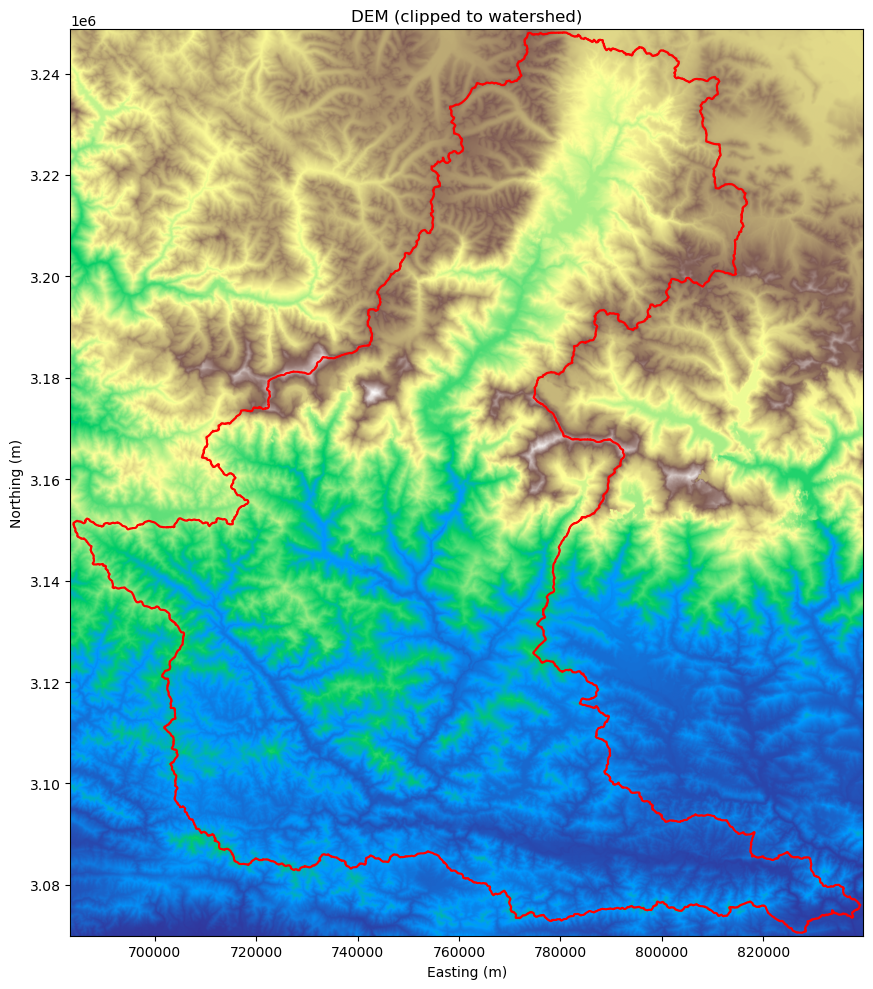

Map 1 (clipped) saved.


In [42]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import geopandas as gpd
from pathlib import Path

results_dir = Path("../results").resolve()
figures_dir = results_dir / "figures"

# --- Load watershed mask and compute a clipped bounding box (with small buffer) ---
with rasterio.open(results_dir / "kali_gandaki_watershed_v2.tif") as src:
    ws = src.read(1)
    ws_transform = src.transform

rows, cols = np.where(ws > 0)
buffer_cells = 20
row_min = max(rows.min() - buffer_cells, 0)
row_max = min(rows.max() + buffer_cells, ws.shape[0] - 1)
col_min = max(cols.min() - buffer_cells, 0)
col_max = min(cols.max() + buffer_cells, ws.shape[1] - 1)

x_min, y_max = ws_transform * (col_min, row_min)
x_max, y_min = ws_transform * (col_max, row_max)
print(f"Clipped view extent: x [{x_min:.0f}, {x_max:.0f}], y [{y_min:.0f}, {y_max:.0f}]")

# --- Map 1 (clipped): DEM masked to watershed ---
with rasterio.open(results_dir / "dem_filled.tif") as src:
    dem = src.read(1, masked=True)
    dem_extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

dem_clipped = np.ma.masked_where(ws == 0, dem)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(dem_clipped, cmap="terrain", extent=dem_extent)
ax.contour(ws, levels=[0.5], colors="red", linewidths=1.5, extent=dem_extent, origin="upper")
ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
ax.set_title("DEM (clipped to watershed)")
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.savefig(str(figures_dir / "map1_dem_watershed.png"), dpi=150)
plt.show()
print("Map 1 (clipped) saved.")

Watershed NoData value: -32768.0
Unique watershed values (sample): [-32768      1]


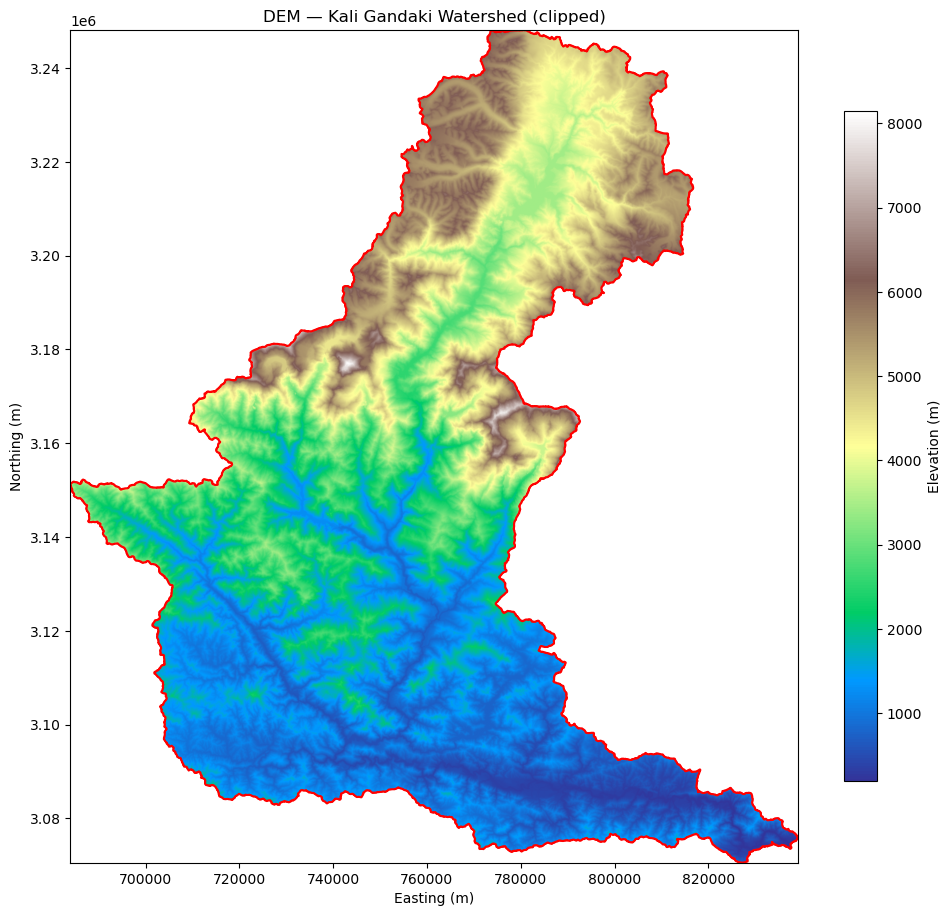

Map 1 (properly clipped) saved.


In [43]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

results_dir = Path("../results").resolve()
figures_dir = results_dir / "figures"

# --- Load watershed raster, correctly identifying valid vs NoData cells ---
with rasterio.open(results_dir / "kali_gandaki_watershed_v2.tif") as src:
    ws = src.read(1)
    ws_nodata = src.nodata
    ws_transform = src.transform

print("Watershed NoData value:", ws_nodata)
print("Unique watershed values (sample):", np.unique(ws)[:10])

# Robust mask: valid watershed cells are > 0 AND not equal to nodata
valid_mask = (ws > 0) & (ws != ws_nodata)

rows, cols = np.where(valid_mask)
row_min, row_max = rows.min(), rows.max()
col_min, col_max = cols.min(), cols.max()

# Crop the actual arrays (not just the view) to this tight bounding box
ws_crop = ws[row_min:row_max+1, col_min:col_max+1]
valid_mask_crop = valid_mask[row_min:row_max+1, col_min:col_max+1]

# Compute the real-world extent of this cropped window
x_min, y_max = ws_transform * (col_min, row_min)
x_max, y_min = ws_transform * (col_max+1, row_max+1)

# --- DEM: crop to same window, mask non-watershed cells as fully transparent ---
with rasterio.open(results_dir / "dem_filled.tif") as src:
    dem = src.read(1)
    dem_nodata = src.nodata

dem_crop = dem[row_min:row_max+1, col_min:col_max+1]
dem_masked = np.ma.masked_where(~valid_mask_crop, dem_crop)

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(dem_masked, cmap="terrain", extent=[x_min, x_max, y_min, y_max])
ax.contour(valid_mask_crop.astype(int), levels=[0.5], colors="red", linewidths=1.5,
           extent=[x_min, x_max, y_min, y_max], origin="upper")
cbar = plt.colorbar(im, ax=ax, shrink=0.7)
cbar.set_label("Elevation (m)")
ax.set_title("DEM — Kali Gandaki Watershed (clipped)")
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.savefig(str(figures_dir / "map1_dem_watershed.png"), dpi=150)
plt.show()
print("Map 1 (properly clipped) saved.")

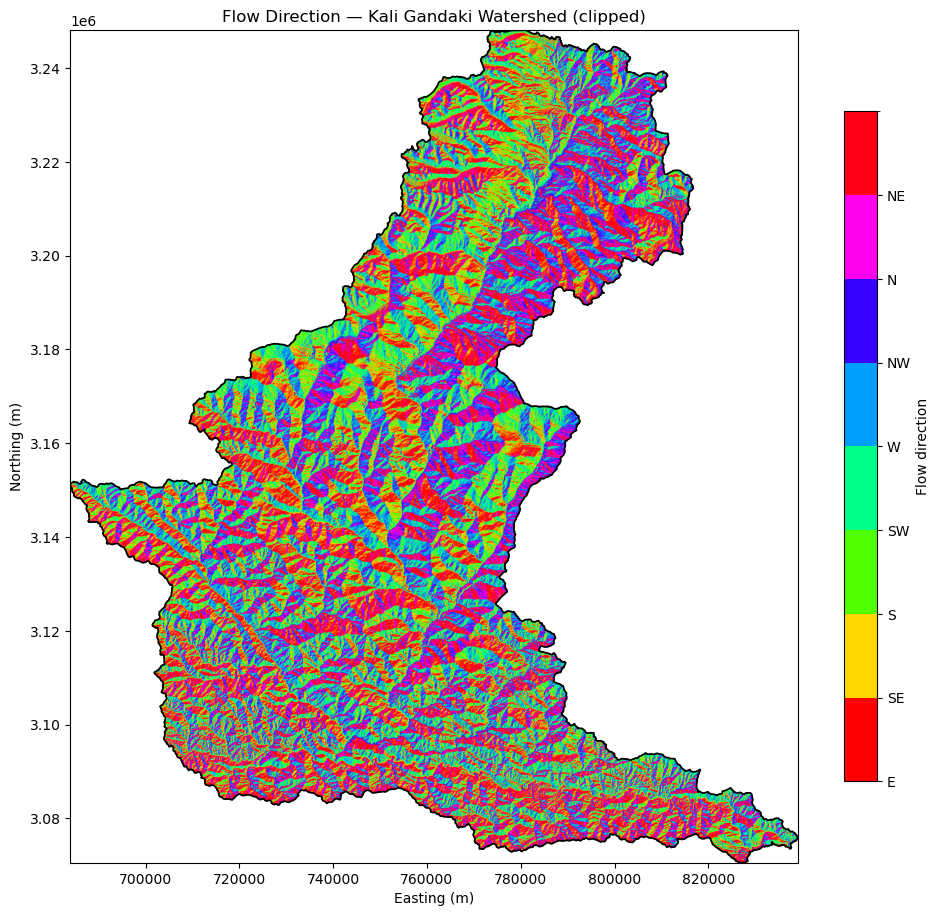

Map 2a (flow direction) saved.


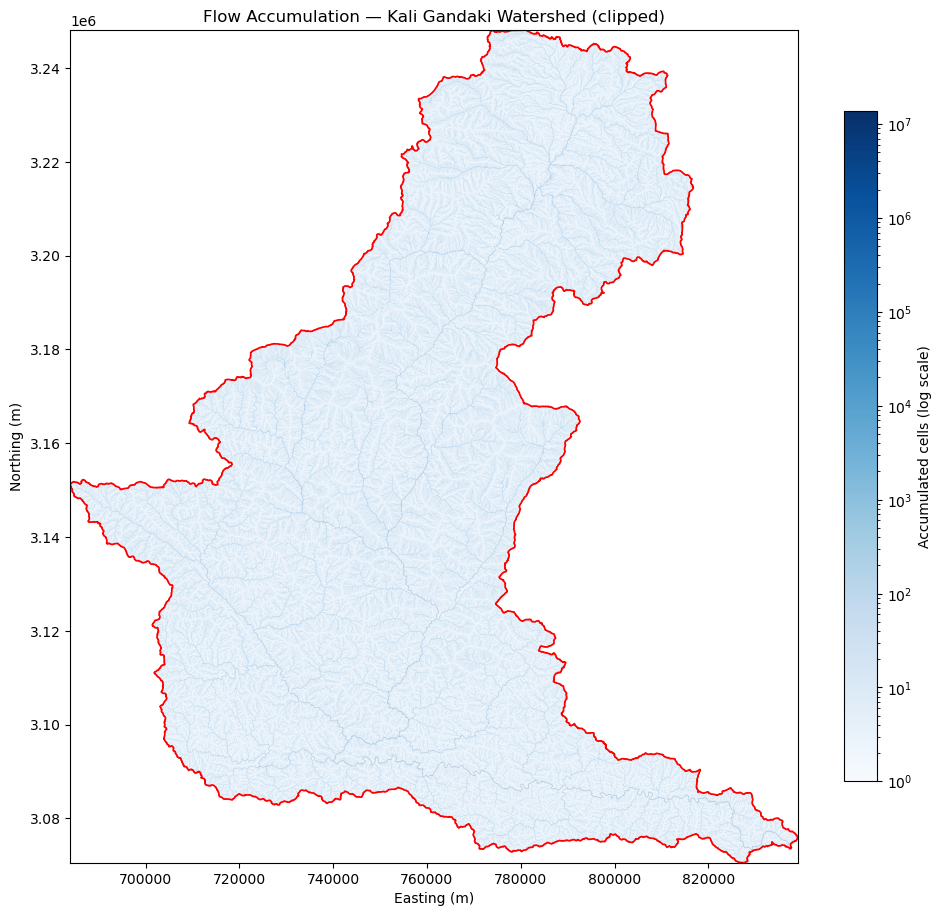

Map 2b (flow accumulation) saved.


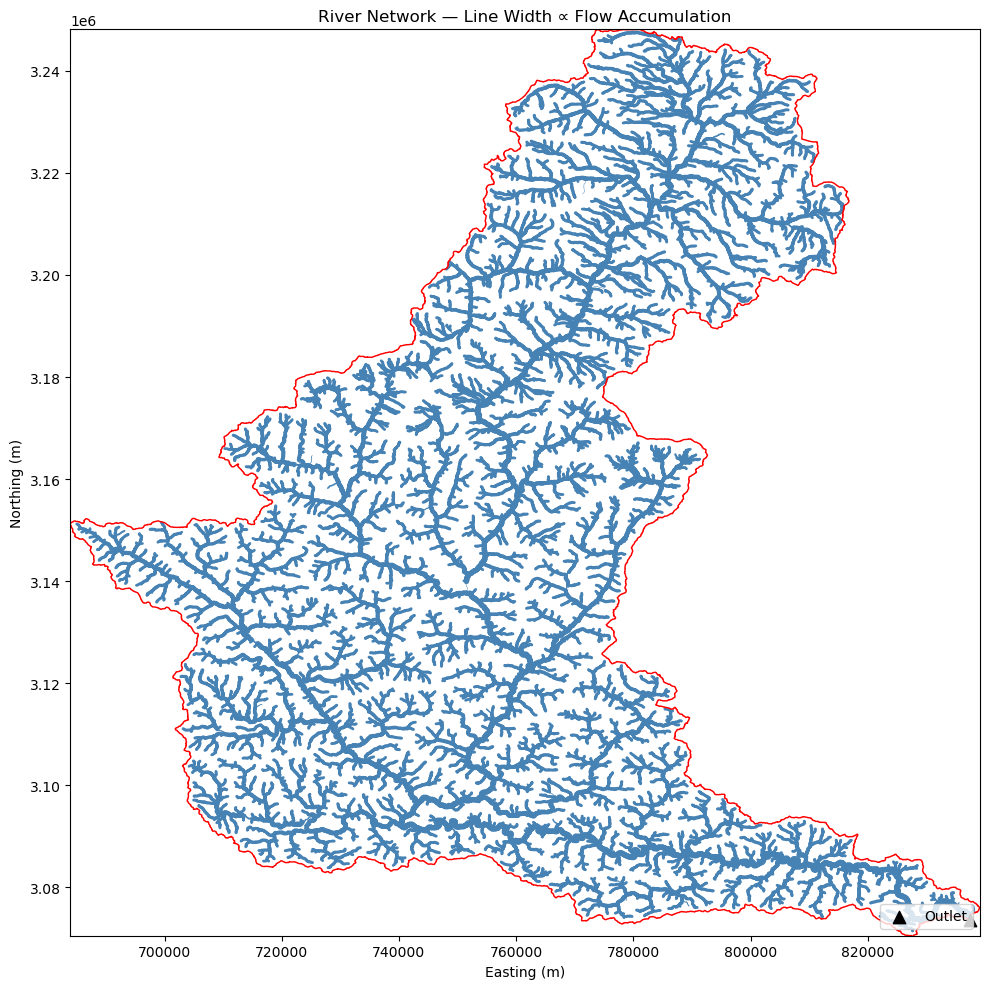

Map 3 (variable width) saved.


In [44]:
import geopandas as gpd
from matplotlib.colors import LogNorm, ListedColormap, BoundaryNorm

# --- Reload streams vector (already CRS-fixed from earlier) ---
streams_gdf = gpd.read_file(results_dir / "river_network.gpkg")

# ============================================================
# Map 2a: Flow direction (clipped, categorical colormap)
# ============================================================
with rasterio.open(results_dir / "flow_direction.tif") as src:
    fdir = src.read(1)
    fdir_nodata = src.nodata

fdir_crop = fdir[row_min:row_max+1, col_min:col_max+1]
fdir_masked = np.ma.masked_where(~valid_mask_crop | (fdir_crop == fdir_nodata) | (fdir_crop == 0), fdir_crop)

# D8 pointer values are powers of 2 (1,2,4,8,16,32,64,128) — categorical, discrete colormap
direction_values = [1, 2, 4, 8, 16, 32, 64, 128]
direction_labels = ["E", "SE", "S", "SW", "W", "NW", "N", "NE"]
cmap_dir = plt.get_cmap("hsv", len(direction_values))
bounds = [0.5, 1.5, 2.5, 4.5, 8.5, 16.5, 32.5, 64.5, 128.5]
norm_dir = BoundaryNorm([1, 2, 4, 8, 16, 32, 64, 128, 256], cmap_dir.N)

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(fdir_masked, cmap=cmap_dir, norm=norm_dir, extent=[x_min, x_max, y_min, y_max])
ax.contour(valid_mask_crop.astype(int), levels=[0.5], colors="black", linewidths=1.2,
           extent=[x_min, x_max, y_min, y_max], origin="upper")
cbar = plt.colorbar(im, ax=ax, ticks=direction_values, shrink=0.7)
cbar.ax.set_yticklabels(direction_labels)
cbar.set_label("Flow direction")
ax.set_title("Flow Direction — Kali Gandaki Watershed (clipped)")
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.savefig(str(figures_dir / "map2a_flow_direction.png"), dpi=150)
plt.show()
print("Map 2a (flow direction) saved.")

# ============================================================
# Map 2b: Flow accumulation (clipped, log scale)
# ============================================================
with rasterio.open(results_dir / "flow_accumulation.tif") as src:
    facc = src.read(1)

facc_crop = facc[row_min:row_max+1, col_min:col_max+1]
facc_masked = np.ma.masked_where(~valid_mask_crop | (facc_crop <= 0), facc_crop)

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(facc_masked, cmap="Blues", norm=LogNorm(), extent=[x_min, x_max, y_min, y_max])
ax.contour(valid_mask_crop.astype(int), levels=[0.5], colors="red", linewidths=1.2,
           extent=[x_min, x_max, y_min, y_max], origin="upper")
cbar = plt.colorbar(im, ax=ax, shrink=0.7)
cbar.set_label("Accumulated cells (log scale)")
ax.set_title("Flow Accumulation — Kali Gandaki Watershed (clipped)")
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.savefig(str(figures_dir / "map2b_flow_accumulation.png"), dpi=150)
plt.show()
print("Map 2b (flow accumulation) saved.")

# ============================================================
# Map 3: Stream network, line width scaled by flow accumulation
# ============================================================
with rasterio.open(results_dir / "flow_accumulation.tif") as src:
    facc_full = src.read(1)
    facc_transform = src.transform

def accum_at_point(x, y):
    row, col = rasterio.transform.rowcol(facc_transform, x, y)
    try:
        return facc_full[row, col]
    except IndexError:
        return 0

# Sample accumulation at each segment's midpoint
mid_accum = []
for geom in streams_gdf.geometry:
    mid = geom.interpolate(0.5, normalized=True)
    mid_accum.append(accum_at_point(mid.x, mid.y))

streams_gdf["mid_accum"] = mid_accum

# Scale line width: log-transform accumulation, map to a reasonable width range
log_accum = np.log10(np.clip(streams_gdf["mid_accum"], 1, None))
lw_min, lw_max = 0.3, 4.0
norm_lw = (log_accum - log_accum.min()) / (log_accum.max() - log_accum.min())
streams_gdf["linewidth"] = lw_min + norm_lw * (lw_max - lw_min)

fig, ax = plt.subplots(figsize=(10, 10))
# Plot each segment individually to allow per-feature linewidth (geopandas .plot() doesn't support this directly)
for _, row_data in streams_gdf.iterrows():
    xs, ys = row_data.geometry.xy
    ax.plot(xs, ys, color="steelblue", linewidth=row_data["linewidth"], solid_capstyle="round")

ax.contour(valid_mask_crop.astype(int), levels=[0.5], colors="red", linewidths=1.0,
           extent=[x_min, x_max, y_min, y_max], origin="upper")
ax.scatter([snap_x2], [snap_y2], color="black", marker="^", s=80, zorder=5, label="Outlet")
ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
ax.legend(loc="lower right")
ax.set_title("River Network — Line Width ∝ Flow Accumulation")
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.savefig(str(figures_dir / "map3_river_network.png"), dpi=150)
plt.show()
print("Map 3 (variable width) saved.")

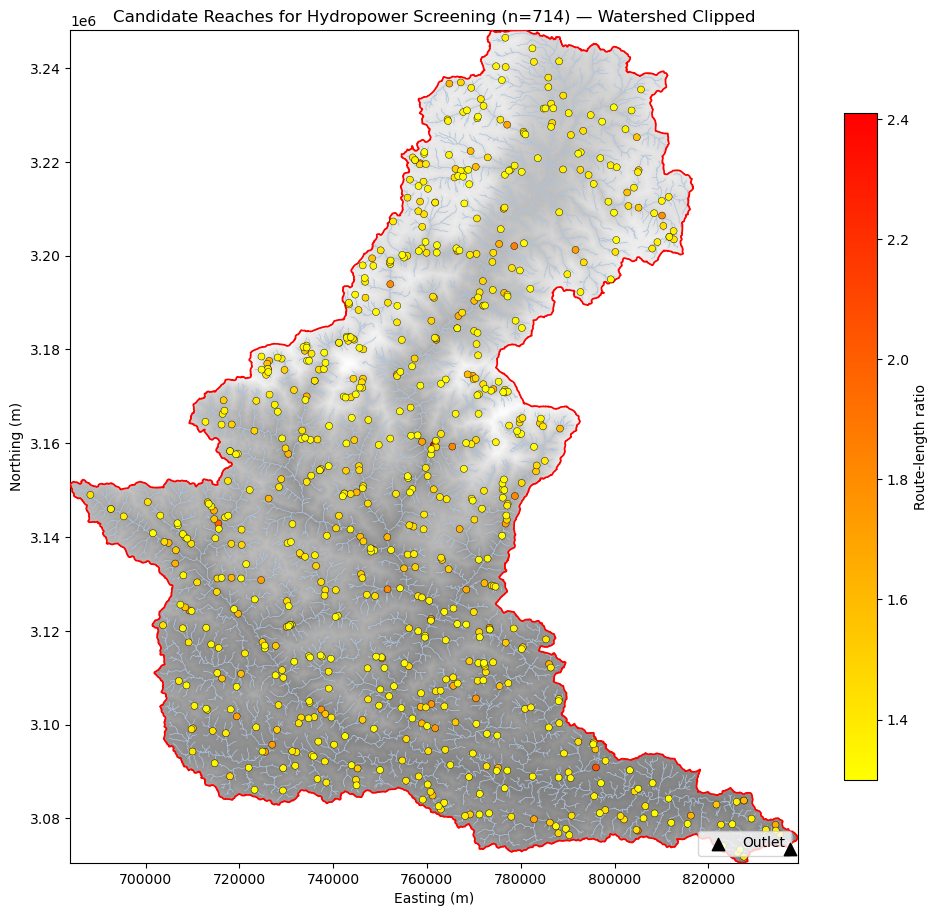

Map 5 (clipped) saved.


In [45]:
import geopandas as gpd
import pandas as pd

# --- Reload candidates if not in memory (kernel may have restarted) ---
candidates_export = pd.read_csv(results_dir / "candidate_reaches.csv")
candidates_gdf = gpd.GeoDataFrame(
    candidates_export,
    geometry=gpd.points_from_xy(candidates_export["downstream_x"], candidates_export["downstream_y"]),
    crs="EPSG:32644"
)

# --- Map 5: Candidate reaches, clipped to watershed ---
fig, ax = plt.subplots(figsize=(10, 10))

# Background: clipped DEM (light, for context)
im_bg = ax.imshow(dem_masked, cmap="Greys_r", extent=[x_min, x_max, y_min, y_max], alpha=0.5)

# Stream network (thin, light blue — reuse the linewidth-scaled version from Map 3 if available, else uniform)
for _, row_data in streams_gdf.iterrows():
    xs, ys = row_data.geometry.xy
    ax.plot(xs, ys, color="lightsteelblue", linewidth=0.5, zorder=2)

# Watershed boundary
ax.contour(valid_mask_crop.astype(int), levels=[0.5], colors="red", linewidths=1.2,
           extent=[x_min, x_max, y_min, y_max], origin="upper", zorder=3)

# Candidate reaches, colored by route-length ratio
sc = ax.scatter(candidates_gdf.geometry.x, candidates_gdf.geometry.y,
                 c=candidates_gdf["route_length_ratio"], cmap="autumn_r",
                 s=25, edgecolor="black", linewidth=0.3, zorder=5)
cbar = plt.colorbar(sc, ax=ax, shrink=0.7)
cbar.set_label("Route-length ratio")

# Outlet marker
ax.scatter([snap_x2], [snap_y2], color="black", marker="^", s=80, zorder=6, label="Outlet")

ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
ax.legend(loc="lower right")
ax.set_title(f"Candidate Reaches for Hydropower Screening (n={len(candidates_gdf)}) — Watershed Clipped")
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.savefig(str(figures_dir / "map5_candidate_reaches.png"), dpi=150)
plt.show()
print("Map 5 (clipped) saved.")

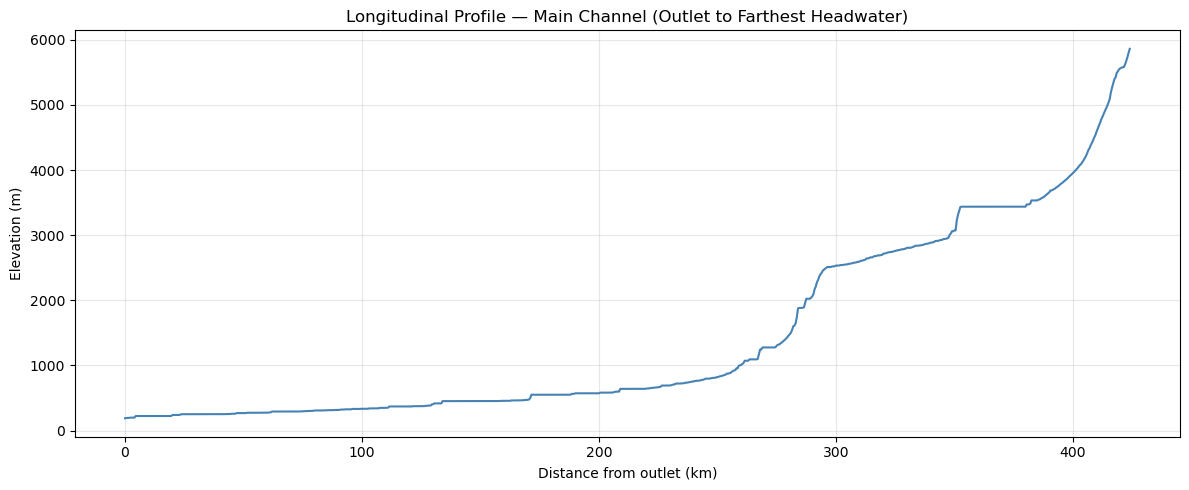

Map 4 saved.

Main channel length: 424.4 km
Elevation range along main channel: 190 - 5862 m


In [38]:
# --- Map 4: Longitudinal elevation profile along the main channel ---
# Identify the "main channel" as the path from outlet to the headwater with the greatest cumulative distance
# (i.e., the longest path through the tree — a reasonable proxy for the primary river course)

farthest_node = max(node_cum_dist, key=node_cum_dist.get)
main_channel_path = nx.shortest_path(G, source=outlet_node, target=farthest_node, weight="length")

# Collect all river points whose edge lies on this path, in order
main_path_edges = set()
for i in range(len(main_channel_path) - 1):
    u, v = main_channel_path[i], main_channel_path[i+1]
    main_path_edges.add(G.edges[u, v]["fid"])

main_profile_pts = river_points_gdf[river_points_gdf["edge_fid"].isin(main_path_edges)].sort_values("cum_dist_from_outlet_m")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(main_profile_pts["cum_dist_from_outlet_m"] / 1000, main_profile_pts["elevation_m"], color="steelblue", lw=1.5)
ax.set_xlabel("Distance from outlet (km)")
ax.set_ylabel("Elevation (m)")
ax.set_title("Longitudinal Profile — Main Channel (Outlet to Farthest Headwater)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str((figures_dir / "map4_longitudinal_profile.png").resolve()), dpi=150)
plt.show()
print("Map 4 saved.")
print(f"\nMain channel length: {node_cum_dist[farthest_node]/1000:.1f} km")
print(f"Elevation range along main channel: {main_profile_pts['elevation_m'].min():.0f} - {main_profile_pts['elevation_m'].max():.0f} m")

In [40]:
import os

# --- Export candidate reaches as CSV (per your original plan's final results table) ---
export_columns = [
    "reach_id", "downstream_x", "downstream_y", "upstream_x", "upstream_y",
    "downstream_elevation_m", "upstream_elevation_m", "delta_z_m",
    "river_distance_m", "euclidean_distance_m",
    "river_gradient_pct", "euclidean_gradient_pct", "route_length_ratio"
]

candidates_export = candidates[export_columns].copy()
candidates_csv_path = str((results_dir / "candidate_reaches.csv").resolve())
candidates_export.to_csv(candidates_csv_path, index=False)
print("Candidate reaches exported to:", candidates_csv_path)
print(f"  {len(candidates_export)} reaches, {len(export_columns)} columns")

# --- Also export the FULL reach table (all 15,649 reaches, not just candidates) for transparency/reproducibility ---
all_reaches_export = all_reaches_df[export_columns].copy()
all_reaches_csv_path = str((results_dir / "all_reaches.csv").resolve())
all_reaches_export.to_csv(all_reaches_csv_path, index=False)
print("Full reach table exported to:", all_reaches_csv_path)
print(f"  {len(all_reaches_export)} reaches")

# --- Export river network as GeoPackage (already fixed CRS earlier) ---
river_network_gpkg_path = str((results_dir / "river_network.gpkg").resolve())
streams_gdf.to_file(river_network_gpkg_path, driver="GPKG")
print("River network exported to:", river_network_gpkg_path)

# --- Export river points too, since they underlie the whole analysis ---
river_points_gpkg_path = str((results_dir / "river_points.gpkg").resolve())
river_points_gdf.to_file(river_points_gpkg_path, driver="GPKG")
print("River points exported to:", river_points_gpkg_path)

# --- Export candidate reaches as a GeoPackage too, for GIS use (not just CSV) ---
candidates_export_gdf = candidates_gdf[export_columns + ["geometry"]].copy()
candidates_gpkg_path = str((results_dir / "candidate_reaches.gpkg").resolve())
candidates_export_gdf.to_file(candidates_gpkg_path, driver="GPKG")
print("Candidate reaches (spatial) exported to:", candidates_gpkg_path)

# --- List everything in results/ to confirm ---
print("\nFinal results/ contents:")
for root, dirs, files in os.walk(results_dir):
    for f in files:
        print(" ", os.path.relpath(os.path.join(root, f), results_dir))

Candidate reaches exported to: D:\kaligandaki\results\candidate_reaches.csv
  714 reaches, 13 columns
Full reach table exported to: D:\kaligandaki\results\all_reaches.csv
  15748 reaches
River network exported to: D:\kaligandaki\results\river_network.gpkg
River points exported to: D:\kaligandaki\results\river_points.gpkg
Candidate reaches (spatial) exported to: D:\kaligandaki\results\candidate_reaches.gpkg

Final results/ contents:
  all_reaches.csv
  candidate_reaches.csv
  candidate_reaches.gpkg
  dem_filled.tif
  flow_accumulation.tif
  flow_direction.tif
  kali_gandaki_watershed.tif
  kali_gandaki_watershed_v2.tif
  pourpoint_snapped.dbf
  pourpoint_snapped.prj
  pourpoint_snapped.shp
  pourpoint_snapped.shx
  pourpoint_snapped_v2.dbf
  pourpoint_snapped_v2.prj
  pourpoint_snapped_v2.shp
  pourpoint_snapped_v2.shx
  river_network.gpkg
  river_points.cpg
  river_points.dbf
  river_points.gpkg
  river_points.prj
  river_points.shp
  river_points.shx
  streams_placeholder.tif
  stream

In [41]:
import shutil

# --- Clean up intermediate/debug files not needed in final published repo ---
files_to_remove = [
    "kali_gandaki_watershed.tif",
    "pourpoint_snapped.dbf", "pourpoint_snapped.prj", "pourpoint_snapped.shp", "pourpoint_snapped.shx",
    "streams_placeholder.tif",
    "river_points.shp", "river_points.dbf", "river_points.shx", "river_points.prj", "river_points.cpg",
    "stream_network.shp", "stream_network.dbf", "stream_network.shx", "stream_network.prj", "stream_network.cpg",
]

for fname in files_to_remove:
    fpath = results_dir / fname
    if fpath.exists():
        fpath.unlink()
        print("Removed:", fname)

print("\nRemaining results/ contents:")
for root, dirs, files in os.walk(results_dir):
    for f in files:
        print(" ", os.path.relpath(os.path.join(root, f), results_dir))

Removed: kali_gandaki_watershed.tif
Removed: pourpoint_snapped.dbf
Removed: pourpoint_snapped.prj
Removed: pourpoint_snapped.shp
Removed: pourpoint_snapped.shx
Removed: streams_placeholder.tif
Removed: river_points.shp
Removed: river_points.dbf
Removed: river_points.shx
Removed: river_points.prj
Removed: river_points.cpg
Removed: stream_network.shp
Removed: stream_network.dbf
Removed: stream_network.shx
Removed: stream_network.prj
Removed: stream_network.cpg

Remaining results/ contents:
  all_reaches.csv
  candidate_reaches.csv
  candidate_reaches.gpkg
  dem_filled.tif
  flow_accumulation.tif
  flow_direction.tif
  kali_gandaki_watershed_v2.tif
  pourpoint_snapped_v2.dbf
  pourpoint_snapped_v2.prj
  pourpoint_snapped_v2.shp
  pourpoint_snapped_v2.shx
  river_network.gpkg
  river_points.gpkg
  stream_network.tif
  figures\contributing_area_histogram.png
  figures\loglog_area_vs_count.png
  figures\map1_dem_watershed.png
  figures\map2_flow_accumulation.png
  figures\map3_river_network.

In [46]:
import rasterio
import numpy as np

# --- Extract contributing area (flow accumulation) at every river point ---
with rasterio.open(results_dir / "flow_accumulation.tif") as src:
    facc_arr = src.read(1)
    facc_transform = src.transform
    facc_res = src.res

cell_area_km2 = (facc_res[0] * facc_res[1]) / 1_000_000

contributing_area = []
for geom in river_points_gdf.geometry:
    row, col = rasterio.transform.rowcol(facc_transform, geom.x, geom.y)
    val = facc_arr[row, col]
    contributing_area.append(val * cell_area_km2)

river_points_gdf["contrib_area_km2"] = contributing_area

# --- Look at the distribution to help choose a "major reach" threshold ---
candidate_thresholds = [10, 25, 50, 100, 200, 500, 1000]
print(f"{'Min contrib. area (km²)':>24} | {'Points remaining':>18} | {'% of all points':>16}")
for t in candidate_thresholds:
    n = (river_points_gdf["contrib_area_km2"] >= t).sum()
    pct = 100 * n / len(river_points_gdf)
    print(f"{t:>24} | {n:>18} | {pct:>15.2f}%")

 Min contrib. area (km²) |   Points remaining |  % of all points
                      10 |               5866 |           35.97%
                      25 |               3918 |           24.02%
                      50 |               2840 |           17.41%
                     100 |               2144 |           13.15%
                     200 |               1605 |            9.84%
                     500 |               1057 |            6.48%
                    1000 |                875 |            5.37%


In [47]:
import numpy as np
import pandas as pd

# --- Build ancestor chain for each edge (list of edge fids from outlet to this edge), via traversal ---
edge_ancestor_chain = {}
visited_nodes = {outlet_node}
stack = [(outlet_node, [])]

while stack:
    node, chain = stack.pop()
    for neighbor in G.neighbors(node):
        if neighbor in visited_nodes:
            continue
        fid = G.edges[node, neighbor]["fid"]
        near, far = edge_near_far[fid]
        if near != node:
            continue
        new_chain = chain + [fid]
        edge_ancestor_chain[fid] = new_chain
        visited_nodes.add(neighbor)
        stack.append((neighbor, new_chain))

# --- Each edge's cumulative-distance range (near-node dist, far-node dist) ---
edge_range = {fid: (node_cum_dist[near], node_cum_dist[far]) for fid, (near, far) in edge_near_far.items()}

# --- Points grouped by edge, sorted by distance, for fast lookup ---
edge_points = {fid: g.sort_values("cum_dist_from_outlet_m").reset_index(drop=True)
               for fid, g in river_points_gdf.groupby("edge_fid")}

print("Ancestor chains built for", len(edge_ancestor_chain), "edges")

Ancestor chains built for 6290 edges


In [48]:
def find_ancestor_point(edge_fid, target_dist):
    """Find the river point at cum_dist_from_outlet_m == target_dist, along this edge's path to the outlet."""
    if target_dist < 0:
        return None
    for fid in edge_ancestor_chain[edge_fid]:
        lo, hi = edge_range[fid]
        if lo - 1e-6 <= target_dist <= hi + 1e-6:
            pts = edge_points.get(fid)
            if pts is None:
                return None
            match = pts[np.isclose(pts["cum_dist_from_outlet_m"], target_dist, atol=1.0)]
            return match.iloc[0] if not match.empty else None
    return None

span_options_m = list(range(500, 10001, 500))  # 500 m to 10 km, in 500 m steps

major_points = river_points_gdf[river_points_gdf["contrib_area_km2"] >= 100].copy()
print("Major-reach starting points to search from:", len(major_points))

results = []
for _, p in major_points.iterrows():
    best = None
    for span in span_options_m:
        target_dist = p["cum_dist_from_outlet_m"] - span
        anc = find_ancestor_point(p["edge_fid"], target_dist)
        if anc is None:
            continue
        dz = p["elevation_m"] - anc["elevation_m"]
        if dz <= 0:
            continue
        euclid = np.hypot(p.geometry.x - anc.geometry.x, p.geometry.y - anc.geometry.y)
        if euclid <= 0:
            continue
        ratio = span / euclid
        if best is None or ratio > best["route_length_ratio"]:
            best = {
                "point_id": p["point_id"],
                "upstream_x": p.geometry.x, "upstream_y": p.geometry.y,
                "downstream_x": anc.geometry.x, "downstream_y": anc.geometry.y,
                "upstream_elevation_m": p["elevation_m"],
                "downstream_elevation_m": anc["elevation_m"],
                "delta_z_m": dz,
                "river_distance_m": span,
                "euclidean_distance_m": euclid,
                "river_gradient_pct": 100 * dz / span,
                "euclidean_gradient_pct": 100 * dz / euclid,
                "route_length_ratio": ratio,
                "contrib_area_km2": p["contrib_area_km2"],
            }
    if best is not None:
        results.append(best)

multiscale_df = pd.DataFrame(results)
print("Points with at least one valid span found:", len(multiscale_df))
print("\nBest-span distribution (which span length won most often):")
print(multiscale_df["river_distance_m"].value_counts().sort_index())
print("\nRoute-length ratio stats (best per point, across all tested spans):")
print(multiscale_df["route_length_ratio"].describe())

Major-reach starting points to search from: 2144
Points with at least one valid span found: 2143

Best-span distribution (which span length won most often):
river_distance_m
500       73
1000     102
1500      95
2000      85
2500      94
3000      78
3500      76
4000      80
4500      75
5000      68
5500      62
6000      72
6500      77
7000      81
7500      84
8000      94
8500     105
9000     117
9500     169
10000    456
Name: count, dtype: int64

Route-length ratio stats (best per point, across all tested spans):
count    2143.000000
mean        1.527007
std         0.460636
min         1.092835
25%         1.266331
50%         1.377376
75%         1.620858
max         7.003038
Name: route_length_ratio, dtype: float64


In [49]:
# --- Distribution of key metrics for the multi-scale results ---
print("ΔZ stats (m):")
print(multiscale_df["delta_z_m"].describe())

print("\nCross-tab: ratio thresholds vs delta_z thresholds (candidate counts)")
for ratio_t in [1.3, 1.5, 2.0]:
    for dz_t in [20, 50, 100]:
        n = ((multiscale_df["route_length_ratio"] >= ratio_t) & (multiscale_df["delta_z_m"] >= dz_t)).sum()
        print(f"  ratio>={ratio_t}, dz>={dz_t}m: {n} candidates ({100*n/len(multiscale_df):.1f}%)")

ΔZ stats (m):
count    2143.000000
mean      142.674893
std       232.460409
min         0.005880
25%        12.998530
50%        56.999580
75%       157.500000
max      1804.000420
Name: delta_z_m, dtype: float64

Cross-tab: ratio thresholds vs delta_z thresholds (candidate counts)
  ratio>=1.3, dz>=20m: 850 candidates (39.7%)
  ratio>=1.3, dz>=50m: 609 candidates (28.4%)
  ratio>=1.3, dz>=100m: 296 candidates (13.8%)
  ratio>=1.5, dz>=20m: 369 candidates (17.2%)
  ratio>=1.5, dz>=50m: 259 candidates (12.1%)
  ratio>=1.5, dz>=100m: 87 candidates (4.1%)
  ratio>=2.0, dz>=20m: 105 candidates (4.9%)
  ratio>=2.0, dz>=50m: 72 candidates (3.4%)
  ratio>=2.0, dz>=100m: 25 candidates (1.2%)


In [50]:
# --- Distribution of euclidean_gradient_pct in the multiscale dataset ---
print("Euclidean gradient (%) stats:")
print(multiscale_df["euclidean_gradient_pct"].describe())

print("\nThree-way cross-tab: ratio>=2.0, delta_z>=30m, plus varying euclidean_gradient thresholds")
base = (multiscale_df["route_length_ratio"] >= 2.0) & (multiscale_df["delta_z_m"] >= 30)
print(f"  ratio>=2.0 & dz>=30m alone: {base.sum()} candidates")
for grad_t in [5, 10, 15, 20, 30]:
    n = (base & (multiscale_df["euclidean_gradient_pct"] >= grad_t)).sum()
    print(f"  + euclidean_gradient>={grad_t}%: {n} candidates")

Euclidean gradient (%) stats:
count    2143.000000
mean        3.297410
std         4.806756
min         0.001339
25%         0.425507
50%         1.435851
75%         3.839022
max        56.654482
Name: euclidean_gradient_pct, dtype: float64

Three-way cross-tab: ratio>=2.0, delta_z>=30m, plus varying euclidean_gradient thresholds
  ratio>=2.0 & dz>=30m alone: 97 candidates
  + euclidean_gradient>=5%: 10 candidates
  + euclidean_gradient>=10%: 8 candidates
  + euclidean_gradient>=15%: 8 candidates
  + euclidean_gradient>=20%: 5 candidates
  + euclidean_gradient>=30%: 0 candidates


In [51]:
# --- Check the >3% threshold, plus lock in the final candidate set ---
final_mask = (
    (multiscale_df["route_length_ratio"] >= 2.0) &
    (multiscale_df["delta_z_m"] >= 30) &
    (multiscale_df["euclidean_gradient_pct"] >= 3)
)
final_candidates = multiscale_df[final_mask].copy()
final_candidates = final_candidates.sort_values("route_length_ratio", ascending=False).reset_index(drop=True)
final_candidates["reach_id"] = range(len(final_candidates))

print(f"Final candidates (ratio>=2.0, ΔZ>=30m, euclidean_gradient>=3%): {len(final_candidates)}")
print(final_candidates[["reach_id", "delta_z_m", "river_distance_m", "euclidean_distance_m",
                          "route_length_ratio", "euclidean_gradient_pct", "contrib_area_km2"]])

Final candidates (ratio>=2.0, ΔZ>=30m, euclidean_gradient>=3%): 38
    reach_id  delta_z_m  river_distance_m  euclidean_distance_m  \
0          0   38.00756              3000            770.894544   
1          1   38.00126              2500            777.029000   
2          2   46.99748              3500           1091.852650   
3          3   81.99874              6500           2138.643781   
4          4   47.00504              4000           1479.180420   
5          5   47.00504              4000           1481.698753   
6          6   41.99160              2000            742.900486   
7          7   87.99076              7500           2931.539896   
8          8   63.99496              5000           1983.714777   
9          9  162.98782              9500           3808.932330   
10        10  179.98572             10000           4099.750521   
11        11   79.99706              6000           2471.143115   
12        12   38.00000               500            207.50716

C:\Users\LOQ\AppData\Local\Temp\ipykernel_3852\2342427001.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("plasma")


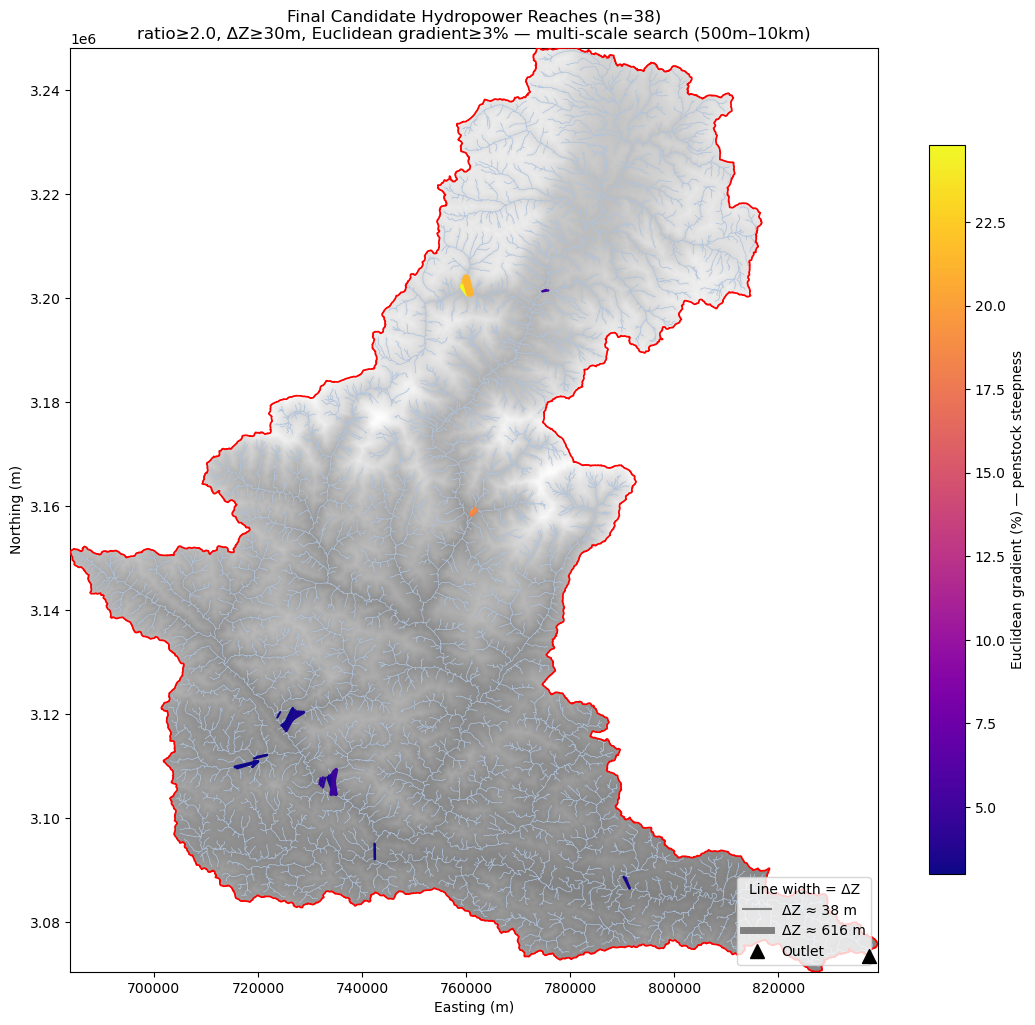

Map 5 v2 (penstock lines, clipped) saved.


In [52]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import LineString, Point
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# --- Build geometries: one LineString per candidate (straight-line penstock shortcut) ---
penstock_lines = [
    LineString([(row.downstream_x, row.downstream_y), (row.upstream_x, row.upstream_y)])
    for row in final_candidates.itertuples()
]
candidates_gdf_final = gpd.GeoDataFrame(final_candidates, geometry=penstock_lines, crs="EPSG:32644")

# Midpoints, for labeling/marker placement
candidates_gdf_final["mid_x"] = candidates_gdf_final.geometry.apply(lambda g: g.interpolate(0.5, normalized=True).x)
candidates_gdf_final["mid_y"] = candidates_gdf_final.geometry.apply(lambda g: g.interpolate(0.5, normalized=True).y)

# --- Map 5 (v2): Final multi-scale candidates, clipped to watershed ---
fig, ax = plt.subplots(figsize=(11, 11))

# Background: clipped DEM
ax.imshow(dem_masked, cmap="Greys_r", extent=[x_min, x_max, y_min, y_max], alpha=0.5)

# River network (thin background context)
for _, row_data in streams_gdf.iterrows():
    xs, ys = row_data.geometry.xy
    ax.plot(xs, ys, color="lightsteelblue", linewidth=0.5, zorder=2)

# Watershed boundary
ax.contour(valid_mask_crop.astype(int), levels=[0.5], colors="red", linewidths=1.2,
           extent=[x_min, x_max, y_min, y_max], origin="upper", zorder=3)

# Penstock candidate lines, colored by euclidean_gradient_pct (steepness), width by delta_z
norm_dz = (candidates_gdf_final["delta_z_m"] - candidates_gdf_final["delta_z_m"].min()) / \
          (candidates_gdf_final["delta_z_m"].max() - candidates_gdf_final["delta_z_m"].min())
linewidths = 1.5 + norm_dz * 4.0

import matplotlib.cm as cm
import matplotlib.colors as mcolors
cmap = cm.get_cmap("plasma")
gradient_norm = mcolors.Normalize(vmin=candidates_gdf_final["euclidean_gradient_pct"].min(),
                                    vmax=candidates_gdf_final["euclidean_gradient_pct"].max())

for i, row_data in candidates_gdf_final.iterrows():
    xs, ys = row_data.geometry.xy
    color = cmap(gradient_norm(row_data["euclidean_gradient_pct"]))
    ax.plot(xs, ys, color=color, linewidth=linewidths.loc[i], zorder=5, solid_capstyle="round")

sm = cm.ScalarMappable(cmap=cmap, norm=gradient_norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.7)
cbar.set_label("Euclidean gradient (%) — penstock steepness")

# Outlet marker
ax.scatter([snap_x2], [snap_y2], color="black", marker="^", s=100, zorder=6, label="Outlet")

# Legend note for line width
legend_handles = [
    mlines.Line2D([], [], color="gray", linewidth=1.5, label=f"ΔZ ≈ {candidates_gdf_final['delta_z_m'].min():.0f} m"),
    mlines.Line2D([], [], color="gray", linewidth=5.0, label=f"ΔZ ≈ {candidates_gdf_final['delta_z_m'].max():.0f} m"),
    mlines.Line2D([], [], color="black", marker="^", linestyle="None", markersize=10, label="Outlet"),
]
ax.legend(handles=legend_handles, loc="lower right", title="Line width = ΔZ")

ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
ax.set_title(f"Final Candidate Hydropower Reaches (n={len(candidates_gdf_final)})\n"
             f"ratio≥2.0, ΔZ≥30m, Euclidean gradient≥3% — multi-scale search (500m–10km)")
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.savefig(str(figures_dir / "map5_candidate_reaches_v2.png"), dpi=200)
plt.show()
print("Map 5 v2 (penstock lines, clipped) saved.")

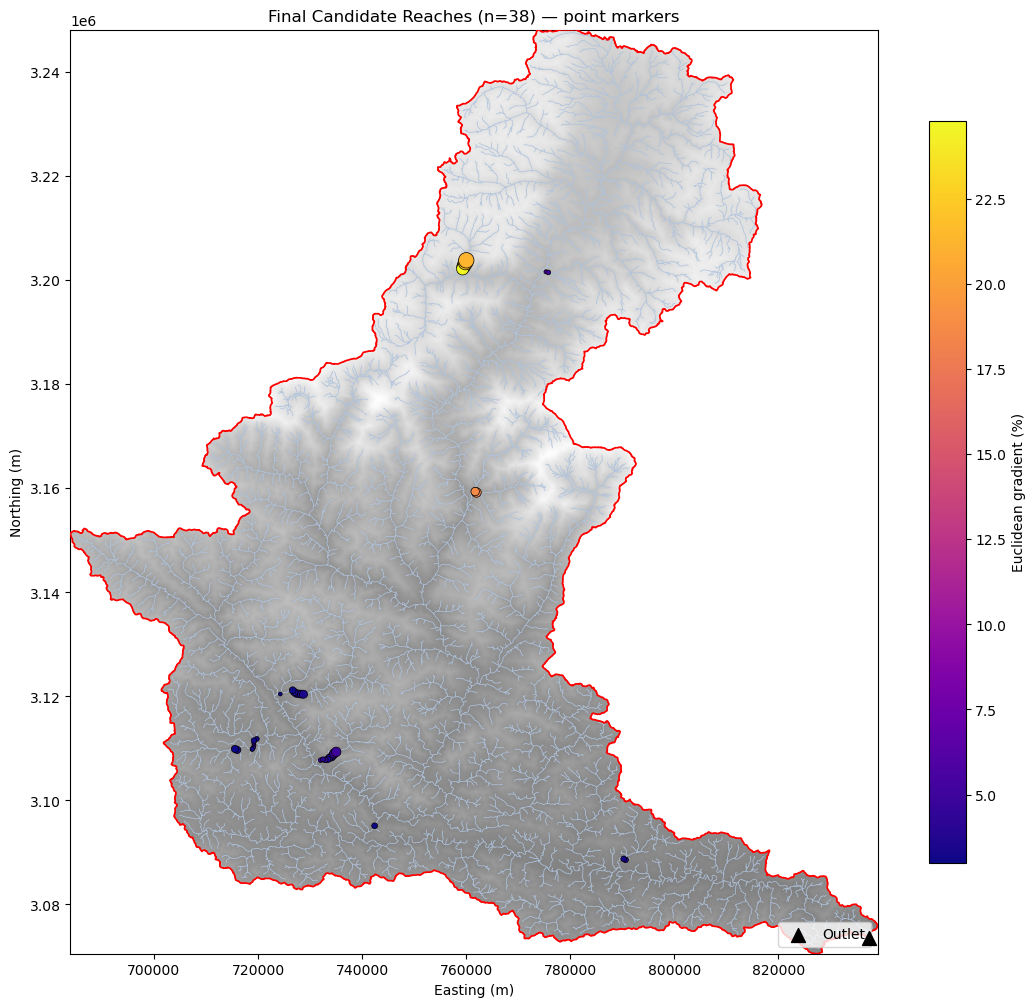

Map 5 (points) saved.


In [53]:
# --- Map 5 (points only) ---
fig, ax = plt.subplots(figsize=(11, 11))

ax.imshow(dem_masked, cmap="Greys_r", extent=[x_min, x_max, y_min, y_max], alpha=0.5)

for _, row_data in streams_gdf.iterrows():
    xs, ys = row_data.geometry.xy
    ax.plot(xs, ys, color="lightsteelblue", linewidth=0.5, zorder=2)

ax.contour(valid_mask_crop.astype(int), levels=[0.5], colors="red", linewidths=1.2,
           extent=[x_min, x_max, y_min, y_max], origin="upper", zorder=3)

sc = ax.scatter(final_candidates["upstream_x"], final_candidates["upstream_y"],
                 c=final_candidates["euclidean_gradient_pct"], cmap="plasma",
                 s=final_candidates["delta_z_m"] / 5,  # size scaled by ΔZ
                 edgecolor="black", linewidth=0.5, zorder=5)
cbar = plt.colorbar(sc, ax=ax, shrink=0.7)
cbar.set_label("Euclidean gradient (%)")

ax.scatter([snap_x2], [snap_y2], color="black", marker="^", s=100, zorder=6, label="Outlet")
ax.legend(loc="lower right")
ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
ax.set_title(f"Final Candidate Reaches (n={len(final_candidates)}) — point markers")
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.savefig(str(figures_dir / "map5_candidate_points.png"), dpi=200)
plt.show()
print("Map 5 (points) saved.")

In [54]:
import numpy as np

# --- Greedy spatial deduplication: keep the best candidate per cluster, remove near-duplicates ---
dedup_radius_m = 1500  # candidates whose upstream points are within this distance are treated as the same site

# Sort by route_length_ratio (or could use a composite score) — best first
sorted_candidates = final_candidates.sort_values("route_length_ratio", ascending=False).reset_index(drop=True)

kept_indices = []
kept_coords = []  # (upstream_x, upstream_y) of kept candidates

for idx, row in sorted_candidates.iterrows():
    pt = np.array([row["upstream_x"], row["upstream_y"]])
    is_duplicate = False
    for kx, ky in kept_coords:
        dist = np.hypot(pt[0] - kx, pt[1] - ky)
        if dist < dedup_radius_m:
            is_duplicate = True
            break
    if not is_duplicate:
        kept_indices.append(idx)
        kept_coords.append((pt[0], pt[1]))

deduped_candidates = sorted_candidates.loc[kept_indices].reset_index(drop=True)
deduped_candidates["reach_id"] = range(len(deduped_candidates))

print(f"Before deduplication: {len(sorted_candidates)} candidates")
print(f"After deduplication (radius={dedup_radius_m}m): {len(deduped_candidates)} distinct sites")
print()
print(deduped_candidates[["reach_id", "delta_z_m", "river_distance_m", "euclidean_distance_m",
                            "route_length_ratio", "euclidean_gradient_pct", "contrib_area_km2"]])

Before deduplication: 38 candidates
After deduplication (radius=1500m): 11 distinct sites

    reach_id  delta_z_m  river_distance_m  euclidean_distance_m  \
0          0   38.00756              3000            770.894544   
1          1   81.99874              6500           2138.643781   
2          2   41.99160              2000            742.900486   
3          3   87.99076              7500           2931.539896   
4          4  162.98782              9500           3808.932330   
5          5   38.00000               500            207.507162   
6          6  143.99202             10000           4170.052031   
7          7  136.99454              9500           4124.566055   
8          8  469.96850              4500           2016.342694   
9          9   55.97942              2500           1173.488333   
10        10   38.99580              2500           1207.910536   

    route_length_ratio  euclidean_gradient_pct  contrib_area_km2  
0             3.891583               

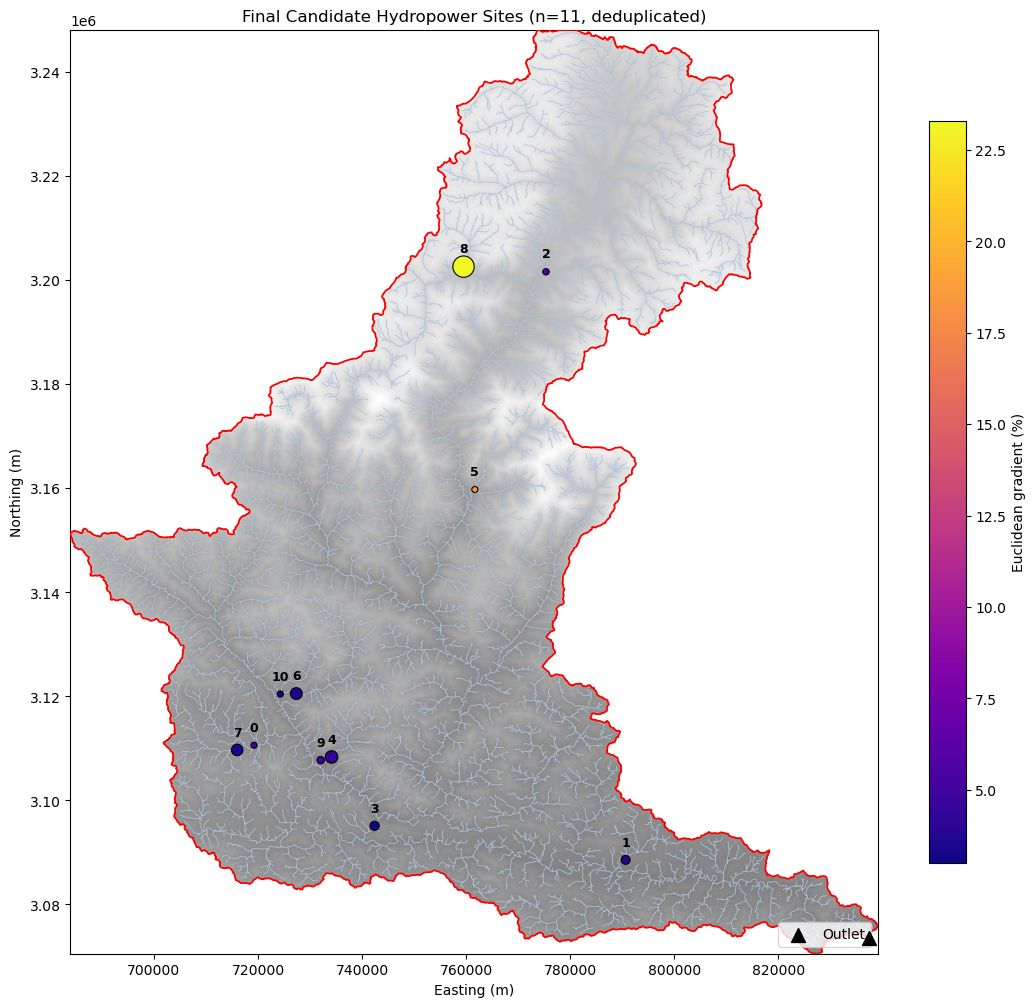

Final Map 5 saved.
Final candidate_reaches.csv saved: 11 sites


In [56]:
# --- Map 5 (final): 11 deduplicated candidate sites, points sized/colored ---
fig, ax = plt.subplots(figsize=(11, 11))

ax.imshow(dem_masked, cmap="Greys_r", extent=[x_min, x_max, y_min, y_max], alpha=0.5)
for _, row_data in streams_gdf.iterrows():
    xs, ys = row_data.geometry.xy
    ax.plot(xs, ys, color="lightsteelblue", linewidth=0.5, zorder=2)
ax.contour(valid_mask_crop.astype(int), levels=[0.5], colors="red", linewidths=1.2,
           extent=[x_min, x_max, y_min, y_max], origin="upper", zorder=3)

sc = ax.scatter(deduped_candidates["upstream_x"], deduped_candidates["upstream_y"],
                 c=deduped_candidates["euclidean_gradient_pct"], cmap="plasma",
                 s=deduped_candidates["delta_z_m"] / 2,
                 edgecolor="black", linewidth=0.8, zorder=5)
cbar = plt.colorbar(sc, ax=ax, shrink=0.7)
cbar.set_label("Euclidean gradient (%)")

# Label each site with its reach_id for reference
for _, row_data in deduped_candidates.iterrows():
    ax.annotate(str(int(row_data["reach_id"])), (row_data["upstream_x"], row_data["upstream_y"]),
                textcoords="offset points", xytext=(0, 8), fontsize=9, fontweight="bold",
                ha="center", va="bottom")
    
ax.scatter([snap_x2], [snap_y2], color="black", marker="^", s=100, zorder=6, label="Outlet")
ax.legend(loc="lower right")
ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
ax.set_title(f"Final Candidate Hydropower Sites (n={len(deduped_candidates)}, deduplicated)")
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.savefig(str(figures_dir / "map5_final_candidates.png"), dpi=200)
plt.show()
print("Final Map 5 saved.")

# --- Export final results ---
export_cols = ["reach_id", "downstream_x", "downstream_y", "upstream_x", "upstream_y",
               "downstream_elevation_m", "upstream_elevation_m", "delta_z_m",
               "river_distance_m", "euclidean_distance_m", "route_length_ratio",
               "river_gradient_pct", "euclidean_gradient_pct", "contrib_area_km2"]

deduped_candidates[export_cols].to_csv(results_dir / "candidate_reaches.csv", index=False)
print("Final candidate_reaches.csv saved:", len(deduped_candidates), "sites")